# Proyecto Big Data - Grupo 5: Uso de Bicicletas (Londres)

**Modulo:** Ingenieria y Analitica de Grandes Cantidades de Datos
**Dataset:** 5 versiones del historico de viajes + `london_stations.csv` (catalogo de estaciones)

**Integrantes (Grupo 5):**
- Nahin Jussephe Cevallos Vinces
- Annabella Noelia Sanchez Guzman
- Martha Maritza Duran Navarrete
- Jesus David Suarez Aspiazu
- Isabella Ivonne Martin Pimentel
- Angelo Saul Zurita Guerrero
- Juan Andres Munizaga Torres

## Preguntas analiticas

| # | Pregunta |
|---|----------|
| Q1 | Como varia la demanda de viajes por hora del dia y dia de la semana? |
| Q2 | Cuales son las estaciones con mayor desequilibrio entre llegadas y salidas? |
| Q3 | Existen rutas (pares origen-destino) que concentran gran parte del trafico total? |

## Herramientas comparadas

| Herramienta | Arquitectura |
|---|---|
| Pandas | DataFrame en memoria, columnar sobre NumPy, mono-hilo |
| DuckDB | Motor OLAP columnar embebido, vectorizado y multi-hilo |
| SQLite | Motor OLTP embebido, orientado a filas |

## Protocolo de medicion

Cada combinacion (version x herramienta x pregunta) es una ejecucion independiente: se carga el archivo desde cero y despues se corre la consulta. Se cronometran por separado carga y query, y el numero que se compara contra el limite de 10 minutos es la suma `carga + query`.

Reglas del benchmark:

- Las tres herramientas materializan completamente el resultado antes de medir.
- Entre ejecuciones se libera la memoria (`del` + `gc.collect()`, conexiones cerradas, archivos temporales borrados).
- Se valida que las tres devuelvan exactamente el mismo resultado antes de comparar tiempos.

## Como usar este notebook

1. Poner la etiqueta de la computadora en `ETIQUETA_EQUIPO`.
2. Elegir que versiones correr en `VERSIONES_A_CORRER`.
3. Ejecutar todo de arriba a abajo.

---
## 0. Configuracion e imports

In [1]:
import os, sys, json, time, csv, gc, sqlite3, platform, tempfile, shutil, threading
from pathlib import Path

import numpy as np
import pandas as pd
import duckdb
import psutil
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

# pyarrow se importa aquí A PROPÓSITO, fuera de todo bloque cronometrado.
# Pandas lo carga de forma perezosa en el primer `read_parquet()`, y ese import
# (varios segundos en frío) se contabilizaría como "tiempo de carga" del Parquet,
# inflando el resultado de la FASE 3 con algo que no es leer datos.
import pyarrow.parquet  # noqa: F401

# ---------------------------------------------------------------- PARÁMETROS
ETIQUETA_EQUIPO = "jesus-macbook"   # <<< CAMBIAR en cada computadora: "equipo-1-ryzen7", "equipo-2-i5"...
LIMITE_SEG      = 600          # 10 minutos: presupuesto de cada (carga + query)
TOP_N           = 20           # filas en los rankings

# Qué versiones barrer. Empezar por las chicas para verificar que todo corre,
# después agregar las grandes. Las que no existan en la carpeta se saltan solas.
VERSIONES_A_CORRER = ["xl"]

# ---------------------------------------------------------------- RUTAS
DIR_PROYECTO = Path.cwd()
ARCHIVO_EST  = DIR_PROYECTO / "london_stations.csv"

# La versión más grande se llama london.csv (sin sufijo), no london_xl.csv
NOMBRES = {"m":  "london_m.csv",
           "l":  "london_l.csv", "xl": "london.csv"}

DIR_SALIDA = DIR_PROYECTO / "salida"
DIR_SALIDA.mkdir(exist_ok=True)

# Los artefactos pesados (.db, .parquet) van a disco LOCAL, no a OneDrive:
# la sincronización en segundo plano distorsiona los tiempos y puede llenar la nube
# con bases de datos de varios GB.
DIR_TRABAJO = Path(tempfile.gettempdir()) / "proyecto_bigdata"
DIR_TRABAJO.mkdir(exist_ok=True)

RUTAS      = {v: DIR_PROYECTO / n for v, n in NOMBRES.items() if (DIR_PROYECTO / n).exists()}
VERSIONES  = [v for v in VERSIONES_A_CORRER if v in RUTAS]
FALTANTES  = [v for v in VERSIONES_A_CORRER if v not in RUTAS]

assert ARCHIVO_EST.exists(), f"Falta el catálogo de estaciones: {ARCHIVO_EST}"
assert VERSIONES, "No se encontró ninguna versión del dataset en la carpeta del proyecto."

print("VERSIONES DISPONIBLES")
for v in VERSIONES:
    print(f"   {v:3s}  {NOMBRES[v]:20s} {RUTAS[v].stat().st_size/1024**3:8.2f} GB")
if FALTANTES:
    print()
    print(f"   No están en la carpeta (se saltan): {', '.join(FALTANTES)}")
    print(f"   Esperados como: {', '.join(NOMBRES[v] for v in FALTANTES)}")

_disco = shutil.disk_usage(str(DIR_TRABAJO))
print()
print(f"Salida  : {DIR_SALIDA}")
print(f"Trabajo : {DIR_TRABAJO}   ({_disco.free/1024**3:,.0f} GB libres)")
print(f"RAM     : {psutil.virtual_memory().total/1024**3:,.1f} GB totales, "
      f"{psutil.virtual_memory().available/1024**3:,.1f} GB disponibles ahora")

VERSIONES DISPONIBLES
   xl   london.csv               4.73 GB

Salida  : /Users/davidsuarez/Desktop/salida
Trabajo : /var/folders/8x/_m9bxv6d3ng8kgfxgzq1bdwr0000gn/T/proyecto_bigdata   (26 GB libres)
RAM     : 8.0 GB totales, 2.3 GB disponibles ahora


---
## 1. Exploracion inicial del dataset

Se perfila con DuckDB, que lee el CSV en streaming sin cargarlo a memoria.

In [3]:
V_EXPLORA = VERSIONES[0]      # la más chica disponible
_ex = duckdb.connect()
_ruta = RUTAS[V_EXPLORA].as_posix()

print(f"ESQUEMA (versión '{V_EXPLORA}')")
print(_ex.execute(f"DESCRIBE SELECT * FROM read_csv_auto('{_ruta}')").df()
          [["column_name", "column_type"]].to_string(index=False))

perfil = _ex.execute(f"""
    SELECT COUNT(*)                                       AS filas,
           COUNT(DISTINCT rental_id)                      AS viajes_unicos,
           COUNT(DISTINCT bike_id)                        AS bicicletas,
           COUNT(DISTINCT start_station_id)               AS estaciones_origen,
           COUNT(DISTINCT end_station_id)                 AS estaciones_destino,
           MIN(start_rental_date_time)                    AS fecha_min,
           MAX(start_rental_date_time)                    AS fecha_max,
           COUNT(*) FILTER (WHERE end_station_id IS NULL) AS nulos_est_destino,
           COUNT(*) FILTER (WHERE duration IS NULL)       AS nulos_duracion,
           COUNT(*) FILTER (WHERE duration = 0)           AS duracion_cero,
           ROUND(AVG(duration)/60, 1)                     AS dur_media_min,
           ROUND(MEDIAN(duration)/60, 1)                  AS dur_mediana_min,
           ROUND(MAX(duration)/3600, 1)                   AS dur_max_horas
    FROM read_csv_auto('{_ruta}')
""").df().T
perfil.columns = ["valor"]
print()
print("PERFIL")
print(perfil.to_string())
_ex.close()

ESQUEMA (versión 'xl')
           column_name column_type
             rental_id      BIGINT
              duration      DOUBLE
               bike_id      DOUBLE
  end_rental_date_time   TIMESTAMP
        end_station_id      DOUBLE
      end_station_name     VARCHAR
start_rental_date_time   TIMESTAMP
      start_station_id      BIGINT
    start_station_name     VARCHAR

PERFIL
                                  valor
filas                          38215560
viajes_unicos                  38215560
bicicletas                        16019
estaciones_origen                   807
estaciones_destino                  808
fecha_min           2016-12-28 00:00:00
fecha_max           2020-09-01 23:54:00
nulos_est_destino                 68213
nulos_duracion                    67617
duracion_cero                      5508
dur_media_min                      21.4
dur_mediana_min                    14.0
dur_max_horas                     551.3


### Filas por version

In [4]:
_ex = duckdb.connect()
filas_por_version = {}
for v in VERSIONES:
    t0 = time.perf_counter()
    filas_por_version[v] = _ex.execute(
        f"SELECT COUNT(*) FROM read_csv_auto('{RUTAS[v].as_posix()}')").fetchone()[0]
    print(f"   {v:3s} {NOMBRES[v]:18s} {filas_por_version[v]:15,} filas  "
          f"({RUTAS[v].stat().st_size/1024**3:6.2f} GB)  [{time.perf_counter()-t0:5.1f} s]")
_ex.close()

tabla_versiones = pd.DataFrame({
    "archivo": [NOMBRES[v] for v in VERSIONES],
    "gb":      [round(RUTAS[v].stat().st_size / 1024**3, 3) for v in VERSIONES],
    "filas":   [filas_por_version[v] for v in VERSIONES],
}, index=VERSIONES)
tabla_versiones["x_vs_xs"] = (tabla_versiones["filas"]
                              / tabla_versiones["filas"].iloc[0]).round(1)
print()
print(tabla_versiones.to_string())

   xl  london.csv              38,215,560 filas  (  4.73 GB)  [  2.4 s]

       archivo     gb     filas  x_vs_xs
xl  london.csv  4.725  38215560      1.0


In [5]:
estaciones = pd.read_csv(ARCHIVO_EST)
print(f"Catálogo de estaciones: {len(estaciones):,} filas")
print(estaciones.head().to_string(index=False))
print()
print("Nulos en el catálogo:")
print(estaciones.isna().sum().to_string())

Catálogo de estaciones: 802 filas
 station_id                         station_name  longitude  latitude
          1            River Street, Clerkenwell  -0.109971   51.5292
          2       Phillimore Gardens, Kensington  -0.197574   51.4996
          3 Christopher Street, Liverpool Street  -0.084606   51.5213
          4      St. Chad's Street, King's Cross  -0.120974   51.5301
          5        Sedding Street, Sloane Square  -0.156876   51.4931

Nulos en el catálogo:
station_id      0
station_name    0
longitude       0
latitude        0


---
## 2. Harness de medicion

- `MuestreadorRAM`: hilo que muestrea la RAM del proceso cada 50 ms para capturar el pico real.
- `ejecutar()`: corre una ejecucion independiente (carga + query), la cronometra y captura errores.
- `barrer()`: recorre versiones x herramientas x preguntas y guarda el avance a disco.

In [6]:
PREGUNTAS = ["Q1", "Q2", "Q3"]
TITULOS = {"Q1": "demanda por hora y día",
           "Q2": "desequilibrio de estaciones",
           "Q3": "rutas origen-destino"}

REGISTRO   = []    # una fila por ejecución
RESULTADOS = {}    # (etapa, version, herramienta, pregunta) -> DataFrame con la respuesta


class MuestreadorRAM(threading.Thread):
    """Muestrea el RSS del proceso en segundo plano para capturar el pico real."""

    def __init__(self, intervalo=0.05):
        super().__init__(daemon=True)
        self.intervalo = intervalo
        self.proc = psutil.Process()
        self.pico = self.proc.memory_info().rss
        self._parar = threading.Event()

    def run(self):
        while not self._parar.is_set():
            try:
                self.pico = max(self.pico, self.proc.memory_info().rss)
            except Exception:
                break
            self._parar.wait(self.intervalo)

    def detener(self):
        self._parar.set()
        self.join(timeout=1)
        return self.pico / 1024**2      # MB


def ruta_benchmarks():
    return DIR_SALIDA / f"benchmarks_{ETIQUETA_EQUIPO}.csv"


def guardar_registro():
    """Guarda el avance a disco. Acumula con lo de corridas anteriores."""
    if not REGISTRO:
        return
    nuevo = pd.DataFrame(REGISTRO)
    ruta = ruta_benchmarks()
    if ruta.exists():
        nuevo = pd.concat([pd.read_csv(ruta), nuevo], ignore_index=True)
    nuevo = nuevo.drop_duplicates(
        subset=["etapa", "version", "equipo", "herramienta", "pregunta"], keep="last")
    nuevo.to_csv(ruta, index=False, encoding="utf-8")

In [7]:
def ejecutar(etapa, version, herramienta, pregunta, impl, guardar_resultado=True):
    """UNA ejecución independiente: carga el archivo desde cero + responde una pregunta.

    Devuelve el dict de registro. Nunca lanza excepción: los fallos (falta de memoria,
    disco lleno, etc.) se capturan y se registran, porque son parte del resultado.
    """
    ruta = impl["ruta"](version)
    gc.collect()
    ram = MuestreadorRAM()
    ram.start()
    reg = {
        "etapa": etapa, "version": version, "equipo": ETIQUETA_EQUIPO,
        "filas_entrada": filas_por_version.get(version),
        "gb_entrada": round(ruta.stat().st_size / 1024**3, 4) if ruta.exists() else None,
        "herramienta": herramienta, "pregunta": pregunta,
        "seg_carga": None, "seg_query": None, "seg_total": None,
        "ram_pico_mb": None, "filas_salida": None, "estado": "ok", "error": None,
    }
    obj = None
    try:
        # A `cargar` se le pasa la pregunta: permite que una implementación prepare
        # solo lo que esa consulta necesita (p. ej. sqlite-opt crea un único índice).
        t0 = time.perf_counter()
        obj = impl["cargar"](ruta, pregunta)
        reg["seg_carga"] = round(time.perf_counter() - t0, 4)

        t1 = time.perf_counter()
        res = impl[pregunta](obj)
        reg["seg_query"] = round(time.perf_counter() - t1, 4)

        reg["seg_total"]    = round(reg["seg_carga"] + reg["seg_query"], 4)
        reg["filas_salida"] = len(res)
        if reg["seg_total"] > LIMITE_SEG:
            reg["estado"] = "EXCEDE"
        if guardar_resultado:
            RESULTADOS[(etapa, version, herramienta, pregunta)] = res
    except MemoryError as e:
        reg["estado"], reg["error"] = "SIN_MEMORIA", f"MemoryError: {e}"
    except Exception as e:
        reg["estado"], reg["error"] = "ERROR", f"{type(e).__name__}: {e}"
    finally:
        try:
            impl["liberar"](obj)
        except Exception:
            pass
        del obj
        gc.collect()
        reg["ram_pico_mb"] = round(ram.detener(), 1)

    REGISTRO.append(reg)
    tot = reg["seg_total"]
    print(f"   {herramienta:10s} {pregunta}  "
          f"carga {reg['seg_carga'] or 0:9.2f} s + query {reg['seg_query'] or 0:9.2f} s "
          f"= {tot if tot is not None else float('nan'):9.2f} s   "
          f"RAM pico {reg['ram_pico_mb']:8,.0f} MB   [{reg['estado']}]")
    if reg["error"]:
        print(f"              -> {reg['error'][:160]}")
    return reg


def barrer(etapa, versiones, implementaciones, guardar_resultado=True):
    """Recorre versiones × herramientas × preguntas. Guarda el avance tras cada bloque."""
    t_ini = time.perf_counter()
    for version in versiones:
        print(f"\n{'='*94}\nVERSIÓN '{version}'  —  {NOMBRES[version]}  "
              f"({filas_por_version.get(version, 0):,} filas)\n{'='*94}")
        for herramienta, impl in implementaciones.items():
            saltar = None
            for pregunta in PREGUNTAS:
                if saltar:
                    REGISTRO.append({
                        "etapa": etapa, "version": version, "equipo": ETIQUETA_EQUIPO,
                        "filas_entrada": filas_por_version.get(version),
                        "gb_entrada": None, "herramienta": herramienta,
                        "pregunta": pregunta, "seg_carga": None, "seg_query": None,
                        "seg_total": None, "ram_pico_mb": None, "filas_salida": None,
                        "estado": "omitido", "error": saltar,
                    })
                    print(f"   {herramienta:10s} {pregunta}  omitido — {saltar}")
                    continue
                reg = ejecutar(etapa, version, herramienta, pregunta, impl,
                               guardar_resultado)
                # Si ya falló o reventó el presupuesto, no tiene sentido repetir la
                # misma carga carísima para las preguntas que faltan.
                if reg["estado"] == "SIN_MEMORIA":
                    saltar = "la carga no cabe en memoria en este equipo"
                elif reg["estado"] == "ERROR":
                    saltar = "falló la ejecución anterior"
                elif reg["estado"] == "EXCEDE":
                    saltar = f"la ejecución anterior superó el límite de {LIMITE_SEG/60:.0f} min"
            guardar_registro()
    print(f"\nBarrido '{etapa}' terminado en {(time.perf_counter()-t_ini)/60:.1f} min. "
          f"Registro guardado en {ruta_benchmarks().name}")

---
## 3. Implementaciones por herramienta

Cada herramienta expone la misma interfaz:

| clave | que hace |
|---|---|
| `ruta(version)` | ubicacion del archivo de entrada |
| `cargar(ruta, pregunta)` | lee el archivo desde cero y devuelve el objeto consultable |
| `Q1` `Q2` `Q3` | reciben ese objeto y devuelven un DataFrame con la respuesta |
| `liberar(obj)` | cierra conexiones y borra temporales |

### Convencion de dia de la semana

Se normaliza a 0 = lunes ... 6 = domingo en las tres herramientas.

| herramienta | nativo | normalizacion |
|---|---|---|
| Pandas | `dt.dayofweek` -> 0 = lunes | ya esta |
| DuckDB | `dayofweek()` -> 0 = domingo | `isodow() - 1` |
| SQLite | `strftime('%w')` -> 0 = domingo | `(strftime('%w') + 6) % 7` |

### 3.1 Pandas

In [8]:
DIAS = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]
COLS_FECHA = ["start_rental_date_time", "end_rental_date_time"]


def pd_cargar(ruta, pregunta=None):
    return pd.read_csv(ruta, parse_dates=COLS_FECHA)


def pd_q1(df):
    ini = df["start_rental_date_time"]
    return (pd.DataFrame({"dia_semana": ini.dt.dayofweek, "hora": ini.dt.hour})
              .groupby(["dia_semana", "hora"]).size().rename("viajes").reset_index()
              .sort_values(["dia_semana", "hora"], ignore_index=True))


def pd_q2(df):
    salidas  = df["start_station_id"].value_counts().rename("salidas")
    llegadas = (df["end_station_id"].dropna().astype("int64")
                  .value_counts().rename("llegadas"))
    q2 = pd.concat([salidas, llegadas], axis=1).fillna(0).astype("int64")
    q2.index.name = "station_id"
    q2 = q2.reset_index()
    q2["neto"]  = q2["llegadas"] - q2["salidas"]
    q2["total"] = q2["llegadas"] + q2["salidas"]
    q2["desequilibrio_pct"] = (q2["neto"] / q2["total"].replace(0, np.nan) * 100).round(2)
    return q2.sort_values(["neto", "station_id"], ignore_index=True)


def pd_q3(df):
    pares = df.dropna(subset=["end_station_id"])
    q3 = (pd.DataFrame({"start_station_id": pares["start_station_id"].to_numpy(),
                        "end_station_id":   pares["end_station_id"].astype("int64").to_numpy()})
            .groupby(["start_station_id", "end_station_id"]).size()
            .rename("viajes").reset_index()
            .sort_values(["viajes", "start_station_id", "end_station_id"],
                         ascending=[False, True, True], ignore_index=True))
    total = int(q3["viajes"].sum())
    q3["pct"]      = q3["viajes"] / total * 100
    q3["pct_acum"] = q3["pct"].cumsum()
    return q3


def pd_liberar(obj):
    pass        # el `del obj` + gc.collect() del harness libera el DataFrame

### 3.2 DuckDB

In [9]:
SQL_DK = {}

SQL_DK["Q1"] = """
    SELECT (isodow(start_rental_date_time) - 1) AS dia_semana,
           hour(start_rental_date_time)         AS hora,
           COUNT(*)                             AS viajes
    FROM viajes
    GROUP BY 1, 2
    ORDER BY 1, 2
"""

# SQLite 3.38 no tiene FULL OUTER JOIN. Se usa la misma forma (CTE de ids + LEFT JOIN)
# en DuckDB, para que las dos consultas sean estructuralmente comparables.
SQL_DK["Q2"] = """
    WITH s AS (SELECT start_station_id AS station_id, COUNT(*) AS salidas
               FROM viajes GROUP BY 1),
         l AS (SELECT CAST(end_station_id AS BIGINT) AS station_id, COUNT(*) AS llegadas
               FROM viajes WHERE end_station_id IS NOT NULL GROUP BY 1),
         ids AS (SELECT station_id FROM s UNION SELECT station_id FROM l)
    SELECT ids.station_id,
           COALESCE(s.salidas, 0)                           AS salidas,
           COALESCE(l.llegadas, 0)                          AS llegadas,
           COALESCE(l.llegadas, 0) - COALESCE(s.salidas, 0) AS neto,
           COALESCE(l.llegadas, 0) + COALESCE(s.salidas, 0) AS total,
           ROUND(100.0 * (COALESCE(l.llegadas, 0) - COALESCE(s.salidas, 0))
                       / NULLIF(COALESCE(l.llegadas, 0) + COALESCE(s.salidas, 0), 0), 2)
                                                            AS desequilibrio_pct
    FROM ids
    LEFT JOIN s ON s.station_id = ids.station_id
    LEFT JOIN l ON l.station_id = ids.station_id
    ORDER BY neto, ids.station_id
"""

SQL_DK["Q3"] = """
    WITH pares AS (SELECT start_station_id,
                          CAST(end_station_id AS BIGINT) AS end_station_id,
                          COUNT(*)                       AS viajes
                   FROM viajes WHERE end_station_id IS NOT NULL GROUP BY 1, 2)
    SELECT start_station_id, end_station_id, viajes,
           100.0 * viajes / SUM(viajes) OVER ()                          AS pct,
           100.0 * SUM(viajes) OVER (ORDER BY viajes DESC,
                                              start_station_id, end_station_id
                                     ROWS UNBOUNDED PRECEDING)
                 / SUM(viajes) OVER ()                                   AS pct_acum
    FROM pares
    ORDER BY viajes DESC, start_station_id, end_station_id
"""

COLS = {"Q1": ["dia_semana", "hora", "viajes"],
        "Q2": ["station_id", "salidas", "llegadas", "neto", "total", "desequilibrio_pct"],
        "Q3": ["start_station_id", "end_station_id", "viajes", "pct", "pct_acum"]}


def dk_cargar(ruta, pregunta=None):
    con = duckdb.connect()
    con.execute(f"""CREATE TABLE viajes AS
                    SELECT * FROM read_csv_auto('{ruta.as_posix()}')""")
    return con


def dk_consulta(con, pregunta, sqls=SQL_DK):
    return pd.DataFrame(con.execute(sqls[pregunta]).fetchall(), columns=COLS[pregunta])


def dk_liberar(con):
    if con is not None:
        con.close()

### 3.3 SQLite

In [10]:
class BaseSQLite:
    """Base temporal: se crea desde cero al cargar y se borra al liberar."""

    def __init__(self, ruta_db):
        self.ruta = ruta_db
        self.con  = sqlite3.connect(ruta_db)

    def cerrar(self):
        try:
            self.con.close()
        finally:
            for suf in ("", "-journal", "-wal", "-shm"):
                p = Path(str(self.ruta) + suf)
                if p.exists():
                    try:
                        p.unlink()
                    except OSError:
                        pass


PRAGMAS_CARGA = ["PRAGMA journal_mode = OFF",     # carga masiva de una sola vez
                 "PRAGMA synchronous = OFF",      # sin fsync por transacción
                 "PRAGMA cache_size = -262144",   # 256 MB de caché de páginas
                 "PRAGMA temp_store = MEMORY"]

DDL_VIAJES = """
CREATE TABLE viajes (
    rental_id              INTEGER,
    duration               REAL,
    bike_id                REAL,
    end_rental_date_time   TEXT,
    end_station_id         REAL,
    end_station_name       TEXT,
    start_rental_date_time TEXT,
    start_station_id       INTEGER,
    start_station_name     TEXT
)
"""


def _ingestar_csv(base, ruta_csv, insert, n_cols, lote=200_000):
    """Lee el CSV en streaming e inserta por lotes. Sin Pandas."""
    con = base.con
    with open(ruta_csv, newline="", encoding="utf-8") as f:
        lector = csv.reader(f)
        next(lector)                                    # cabecera
        buf = []
        for fila in lector:
            buf.append([v if v != "" else None for v in fila[:n_cols]])
            if len(buf) >= lote:
                con.executemany(insert, buf)
                buf.clear()
        if buf:
            con.executemany(insert, buf)
    con.commit()


def lt_cargar(ruta, pregunta=None):
    base = BaseSQLite(DIR_TRABAJO / f"tmp_{os.getpid()}_{time.time_ns()}.db")
    for p in PRAGMAS_CARGA:
        base.con.execute(p)
    base.con.execute(DDL_VIAJES)
    _ingestar_csv(base, ruta, "INSERT INTO viajes VALUES (?,?,?,?,?,?,?,?,?)", 9)
    return base


SQL_LT = {}

# strftime('%w') -> 0=domingo..6=sábado; (x+6)%7 lo lleva a 0=lunes..6=domingo.
# SQLite guarda los timestamps como TEXTO: hay que parsearlos fila por fila, que es
# una de las razones por las que se espera que sea la más lenta en las agregaciones.
SQL_LT["Q1"] = """
    SELECT (CAST(strftime('%w', start_rental_date_time) AS INTEGER) + 6) % 7 AS dia_semana,
           CAST(strftime('%H', start_rental_date_time) AS INTEGER)           AS hora,
           COUNT(*)                                                          AS viajes
    FROM viajes
    GROUP BY 1, 2
    ORDER BY 1, 2
"""

SQL_LT["Q2"] = """
    WITH s AS (SELECT start_station_id AS station_id, COUNT(*) AS salidas
               FROM viajes GROUP BY 1),
         l AS (SELECT CAST(end_station_id AS INTEGER) AS station_id, COUNT(*) AS llegadas
               FROM viajes WHERE end_station_id IS NOT NULL GROUP BY 1),
         ids AS (SELECT station_id FROM s UNION SELECT station_id FROM l)
    SELECT ids.station_id,
           COALESCE(s.salidas, 0)                           AS salidas,
           COALESCE(l.llegadas, 0)                          AS llegadas,
           COALESCE(l.llegadas, 0) - COALESCE(s.salidas, 0) AS neto,
           COALESCE(l.llegadas, 0) + COALESCE(s.salidas, 0) AS total,
           ROUND(100.0 * (COALESCE(l.llegadas, 0) - COALESCE(s.salidas, 0))
                       / NULLIF(COALESCE(l.llegadas, 0) + COALESCE(s.salidas, 0), 0), 2)
                                                            AS desequilibrio_pct
    FROM ids
    LEFT JOIN s ON s.station_id = ids.station_id
    LEFT JOIN l ON l.station_id = ids.station_id
    ORDER BY neto, ids.station_id
"""

SQL_LT["Q3"] = """
    WITH pares AS (SELECT start_station_id,
                          CAST(end_station_id AS INTEGER) AS end_station_id,
                          COUNT(*)                        AS viajes
                   FROM viajes WHERE end_station_id IS NOT NULL GROUP BY 1, 2),
         tot AS (SELECT SUM(viajes) AS n FROM pares)
    SELECT start_station_id, end_station_id, viajes,
           100.0 * viajes / (SELECT n FROM tot)                            AS pct,
           100.0 * SUM(viajes) OVER (ORDER BY viajes DESC,
                                              start_station_id, end_station_id
                                     ROWS UNBOUNDED PRECEDING)
                 / (SELECT n FROM tot)                                     AS pct_acum
    FROM pares
    ORDER BY viajes DESC, start_station_id, end_station_id
"""


def lt_consulta(base, pregunta, sqls=SQL_LT):
    return pd.DataFrame(base.con.execute(sqls[pregunta]).fetchall(), columns=COLS[pregunta])


def lt_liberar(base):
    if base is not None:
        base.cerrar()

### 3.4 Registro de implementaciones

In [11]:
IMPL_BASE = {
    "pandas": {"ruta": lambda v: RUTAS[v], "cargar": pd_cargar, "liberar": pd_liberar,
               "Q1": pd_q1, "Q2": pd_q2, "Q3": pd_q3},
    "duckdb": {"ruta": lambda v: RUTAS[v], "cargar": dk_cargar, "liberar": dk_liberar,
               "Q1": lambda c: dk_consulta(c, "Q1"),
               "Q2": lambda c: dk_consulta(c, "Q2"),
               "Q3": lambda c: dk_consulta(c, "Q3")},
    "sqlite": {"ruta": lambda v: RUTAS[v], "cargar": lt_cargar, "liberar": lt_liberar,
               "Q1": lambda b: lt_consulta(b, "Q1"),
               "Q2": lambda b: lt_consulta(b, "Q2"),
               "Q3": lambda b: lt_consulta(b, "Q3")},
}

# Prueba de humo en la versión más chica: verifica que las 3 implementaciones corren
# y devuelven lo mismo, antes de lanzar el barrido largo.
_v = VERSIONES[0]
print(f"Prueba de humo en la versión '{_v}' ({filas_por_version[_v]:,} filas)")
_chk = {}
for _h, _impl in IMPL_BASE.items():
    _obj = _impl["cargar"](_impl["ruta"](_v), "Q1")
    _chk[_h] = {p: _impl[p](_obj) for p in PREGUNTAS}
    _impl["liberar"](_obj)
    del _obj
    gc.collect()
    print(f"   {_h:8s} Q1 {len(_chk[_h]['Q1']):>4} filas | "
          f"Q2 {len(_chk[_h]['Q2']):>5} filas | Q3 {len(_chk[_h]['Q3']):>8,} filas")

for _p in PREGUNTAS:
    _ref = _chk["pandas"][_p]
    _igual = all(len(_chk[h][_p]) == len(_ref) and
                 _chk[h][_p]["viajes" if _p != "Q2" else "neto"].astype("int64")
                     .equals(_ref["viajes" if _p != "Q2" else "neto"].astype("int64"))
                 for h in _chk)
    print(f"   {_p}: {'las 3 coinciden' if _igual else 'DIFIEREN — revisar antes de barrer'}")
del _chk
gc.collect()

Prueba de humo en la versión 'xl' (38,215,560 filas)
   pandas   Q1  168 filas | Q2   808 filas | Q3  510,672 filas
   duckdb   Q1  168 filas | Q2   808 filas | Q3  510,672 filas
   sqlite   Q1  168 filas | Q2   808 filas | Q3  510,672 filas
   Q1: las 3 coinciden
   Q2: las 3 coinciden
   Q3: las 3 coinciden


0

---
## 4. FASE 2 - Barrido completo (linea base)

Recorre cada version x cada herramienta x cada pregunta. El avance se guarda a disco despues de cada bloque.

In [12]:
barrer("base", VERSIONES, IMPL_BASE)


VERSIÓN 'xl'  —  london.csv  (38,215,560 filas)
   pandas     Q1  carga     56.73 s + query      2.73 s =     59.45 s   RAM pico    4,480 MB   [ok]
   pandas     Q2  carga     55.53 s + query      1.60 s =     57.13 s   RAM pico    4,522 MB   [ok]
   pandas     Q3  carga     57.17 s + query     21.62 s =     78.79 s   RAM pico    3,935 MB   [ok]
   duckdb     Q1  carga      9.04 s + query      0.25 s =      9.30 s   RAM pico    1,394 MB   [ok]
   duckdb     Q2  carga      8.20 s + query      0.21 s =      8.42 s   RAM pico    1,396 MB   [ok]
   duckdb     Q3  carga      8.15 s + query      1.44 s =      9.59 s   RAM pico    2,208 MB   [ok]
   sqlite     Q1  carga     99.77 s + query     28.64 s =    128.42 s   RAM pico    2,837 MB   [ok]
   sqlite     Q2  carga    108.83 s + query     82.64 s =    191.47 s   RAM pico    2,837 MB   [ok]
   sqlite     Q3  carga    104.56 s + query     48.19 s =    152.75 s   RAM pico    1,869 MB   [ok]

Barrido 'base' terminado en 11.6 min. Registro gua

---
## 5. Validacion cruzada

Se compara cada herramienta contra Pandas como referencia, con tolerancia numerica en columnas de porcentaje.

In [13]:
CLAVES = {"Q1": ["dia_semana", "hora"],
          "Q2": ["station_id"],
          "Q3": ["start_station_id", "end_station_id"]}


def comparar(etapa, version, referencia="pandas", tol=1e-6):
    """Compara las herramientas contra `referencia` para una (etapa, versión)."""
    base = RESULTADOS.get((etapa, version, referencia, "Q1"))
    if base is None:
        print(f"   versión '{version}': {referencia} no completó — no hay referencia")
        return None
    todo_ok = True
    for preg in PREGUNTAS:
        ref = RESULTADOS[(etapa, version, referencia, preg)].sort_values(
            CLAVES[preg], ignore_index=True)
        for herr in IMPL_BASE:
            if herr == referencia:
                continue
            otro = RESULTADOS.get((etapa, version, herr, preg))
            if otro is None:
                print(f"   {version:3s} {preg} {herr:8s} -> no completó")
                todo_ok = False
                continue
            otro = otro.sort_values(CLAVES[preg], ignore_index=True)
            fallos = []
            if len(ref) != len(otro):
                fallos.append(f"filas {len(ref):,} vs {len(otro):,}")
            else:
                for col in ref.columns:
                    a, b = ref[col], otro[col]
                    if pd.api.types.is_float_dtype(a) or pd.api.types.is_float_dtype(b):
                        ok = np.allclose(a.astype(float).fillna(-999),
                                         b.astype(float).fillna(-999), atol=tol)
                    else:
                        ok = a.astype("int64").equals(b.astype("int64"))
                    if not ok:
                        fallos.append(f"columna '{col}'")
            todo_ok &= not fallos
            print(f"   {version:3s} {preg} {herr:8s} -> "
                  f"{'IDÉNTICO' if not fallos else 'DIFIERE: ' + '; '.join(fallos)}")
    return todo_ok


print("VALIDACIÓN CRUZADA — etapa 'base'")
_estado = {v: comparar("base", v) for v in VERSIONES}
print()
_completas = [v for v, ok in _estado.items() if ok]
print(f"Versiones con las 3 herramientas coincidiendo: "
      f"{', '.join(_completas) if _completas else 'ninguna'}")

VALIDACIÓN CRUZADA — etapa 'base'
   xl  Q1 duckdb   -> IDÉNTICO
   xl  Q1 sqlite   -> IDÉNTICO
   xl  Q2 duckdb   -> IDÉNTICO
   xl  Q2 sqlite   -> IDÉNTICO
   xl  Q3 duckdb   -> IDÉNTICO
   xl  Q3 sqlite   -> IDÉNTICO

Versiones con las 3 herramientas coincidiendo: xl


In [14]:
# Cuadre aritmético: los totales tienen que cerrar contra el nº de filas del archivo
print("CUADRE ARITMÉTICO")
for v in VERSIONES:
    q1 = RESULTADOS.get(("base", v, "pandas", "Q1"))
    q2 = RESULTADOS.get(("base", v, "pandas", "Q2"))
    q3 = RESULTADOS.get(("base", v, "pandas", "Q3"))
    if q1 is None:
        q1 = RESULTADOS.get(("base", v, "duckdb", "Q1"))
        q2 = RESULTADOS.get(("base", v, "duckdb", "Q2"))
        q3 = RESULTADOS.get(("base", v, "duckdb", "Q3"))
    if q1 is None:
        print(f"   {v:3s} sin resultados")
        continue
    n        = filas_por_version[v]
    n_q1     = int(q1["viajes"].sum())
    n_sal    = int(q2["salidas"].sum())
    n_lle    = int(q2["llegadas"].sum())
    n_q3     = int(q3["viajes"].sum())
    print(f"   {v:3s} filas={n:>12,} | Q1 suma={n_q1:>12,} {'ok' if n_q1 == n else 'NO CUADRA'}"
          f" | Q2 salidas={n_sal:>12,} {'ok' if n_sal == n else 'NO CUADRA'}"
          f" | Q2 llegadas={n_lle:>12,} = Q3 total {'ok' if n_q3 == n_lle else 'NO CUADRA'}"
          f" | sin destino={n - n_lle:>10,}")

CUADRE ARITMÉTICO
   xl  filas=  38,215,560 | Q1 suma=  38,215,560 ok | Q2 salidas=  38,215,560 ok | Q2 llegadas=  38,147,347 = Q3 total ok | sin destino=    68,213


In [15]:
# Los resultados de Q3 ocupan memoria. Se conserva solo la versión más grande que completó
# (es la que alimenta la sección de respuestas) y se liberan las demás.
V_RESPUESTAS = None
for v in reversed(VERSIONES):
    if any((("base", v, h, "Q3") in RESULTADOS) for h in IMPL_BASE):
        V_RESPUESTAS = v
        break

for clave in [k for k in list(RESULTADOS)
              if k[0] == "base" and k[1] != V_RESPUESTAS and k[3] == "Q3"]:
    del RESULTADOS[clave]
gc.collect()
print(f"Las respuestas de la sección 9 se construyen con la versión '{V_RESPUESTAS}' "
      f"({filas_por_version[V_RESPUESTAS]:,} filas).")

Las respuestas de la sección 9 se construyen con la versión 'xl' (38,215,560 filas).


---
## 6. FASE 2 - Resultados de rendimiento

In [16]:
def cargar_bench(etapas=None):
    """Une lo medido en esta sesión con lo que ya estaba guardado en disco.

    Importante para las corridas por partes: si se barrió 'xs' ayer y 'l' hoy, o si el
    ETL se saltó porque sus artefactos ya existían, las mediciones viejas siguen contando.
    """
    partes = []
    if ruta_benchmarks().exists():
        partes.append(pd.read_csv(ruta_benchmarks()))
    if REGISTRO:
        partes.append(pd.DataFrame(REGISTRO))
    if not partes:
        raise RuntimeError("No hay mediciones: hay que correr barrer() primero.")
    df = pd.concat(partes, ignore_index=True).drop_duplicates(
        subset=["etapa", "version", "equipo", "herramienta", "pregunta"], keep="last")
    df = df[df.equipo == ETIQUETA_EQUIPO]
    if etapas:
        df = df[df.etapa.isin(etapas)]
    df["version"] = pd.Categorical(df["version"], categories=list(NOMBRES), ordered=True)
    return df.sort_values(["etapa", "version", "herramienta", "pregunta"])


bench = cargar_bench(["base"])

print("TIEMPO TOTAL (carga + query) EN SEGUNDOS")
tabla_total = bench.pivot_table(index=["version", "pregunta"], columns="herramienta",
                                values="seg_total", aggfunc="last", observed=True)
print(tabla_total.round(2).to_string())

print()
print("DESGLOSE CARGA vs QUERY (segundos)")
desglose = bench.pivot_table(index=["version", "herramienta"],
                             columns="pregunta", values=["seg_carga", "seg_query"],
                             aggfunc="last", observed=True)
print(desglose.round(2).to_string())

print()
print("ESTADO DE CADA EJECUCIÓN")
estados = bench.pivot_table(index=["version", "herramienta"], columns="pregunta",
                            values="estado", aggfunc="last", observed=True)
print(estados.to_string())

_malos = bench[bench.estado != "ok"]
print()
if _malos.empty:
    print(f"Todas las ejecuciones completaron dentro del límite de {LIMITE_SEG/60:.0f} minutos.")
else:
    print(f"EJECUCIONES QUE NO COMPLETARON ({len(_malos)}):")
    print(_malos[["version", "herramienta", "pregunta", "estado", "error"]]
          .to_string(index=False))

TIEMPO TOTAL (carga + query) EN SEGUNDOS
herramienta       duckdb  pandas  sqlite
version pregunta                        
xl      Q1          9.30   59.45  128.42
        Q2          8.42   57.13  191.47
        Q3          9.59   78.79  152.75

DESGLOSE CARGA vs QUERY (segundos)
                    seg_carga                 seg_query              
pregunta                   Q1      Q2      Q3        Q1     Q2     Q3
version herramienta                                                  
xl      duckdb           9.04    8.20    8.15      0.25   0.21   1.44
        pandas          56.73   55.53   57.17      2.73   1.60  21.62
        sqlite          99.77  108.83  104.56     28.64  82.64  48.19

ESTADO DE CADA EJECUCIÓN
pregunta             Q1  Q2  Q3
version herramienta            
xl      duckdb       ok  ok  ok
        pandas       ok  ok  ok
        sqlite       ok  ok  ok

Todas las ejecuciones completaron dentro del límite de 10 minutos.


In [17]:
print("PICO DE RAM DEL PROCESO (MB), maximo observado por version y herramienta")
ram = bench.pivot_table(index="version", columns="herramienta",
                        values="ram_pico_mb", aggfunc="max", observed=True)
print(ram.round(0).to_string())

_ram_total = psutil.virtual_memory().total / 1024**2
print()
print(f"RAM física del equipo: {_ram_total:,.0f} MB")
print("Uso del pico respecto a la RAM total (%):")
print((ram / _ram_total * 100).round(1).to_string())

PICO DE RAM DEL PROCESO (MB) — máximo observado por versión y herramienta
herramienta  duckdb  pandas  sqlite
version                            
xl           2208.0  4522.0  2837.0

RAM física del equipo: 8,192 MB
Uso del pico respecto a la RAM total (%):
herramienta  duckdb  pandas  sqlite
version                            
xl             27.0    55.2    34.6


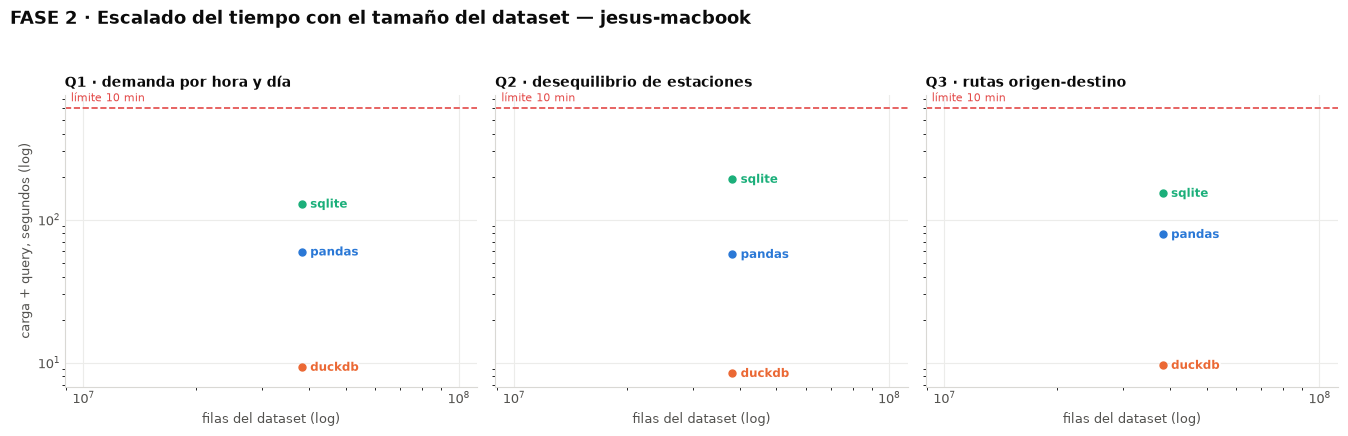

In [18]:
# Paleta categórica de orden fijo: azul / naranja / aqua (no se cicla ni se reasigna)
COLOR_HERR = {"pandas": "#2a78d6", "duckdb": "#eb6834", "sqlite": "#1baf7a"}
TINTA, TINTA2 = "#0b0b0b", "#52514e"
HALO = [pe.withStroke(linewidth=2.8, foreground="white")]


def estilo_ejes(ax):
    ax.set_facecolor("white")
    for lado in ("top", "right"):
        ax.spines[lado].set_visible(False)
    for lado in ("left", "bottom"):
        ax.spines[lado].set_color("#d9d8d4")
    ax.tick_params(colors=TINTA2, labelsize=9, length=0)
    ax.grid(color="#ececea", linewidth=0.8)
    ax.set_axisbelow(True)


# ESCALADO: tiempo total vs. nº de filas, una faceta por pregunta.
# Log-log, así una recta de pendiente 1 significa escalado lineal O(n).
ok = bench[bench.estado.isin(["ok", "EXCEDE"])]
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.4), sharey=True)
for ax, preg in zip(axes, PREGUNTAS):
    sub = ok[ok.pregunta == preg]
    for herr in ["pandas", "duckdb", "sqlite"]:
        s = sub[sub.herramienta == herr].sort_values("filas_entrada")
        if s.empty:
            continue
        ax.plot(s["filas_entrada"], s["seg_total"], marker="o", markersize=5,
                linewidth=2, color=COLOR_HERR[herr], label=herr)
        ult = s.iloc[-1]
        ax.annotate(herr, (ult["filas_entrada"], ult["seg_total"]),
                    xytext=(6, 0), textcoords="offset points", fontsize=8.5,
                    color=COLOR_HERR[herr], fontweight="bold", va="center",
                    path_effects=HALO)
    ax.axhline(LIMITE_SEG, color="#e34948", linewidth=1.2, linestyle="--")
    ax.text(0.015, LIMITE_SEG * 1.12, f"límite {LIMITE_SEG/60:.0f} min",
            transform=ax.get_yaxis_transform(), fontsize=8, color="#e34948")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("filas del dataset (log)", color=TINTA2, fontsize=9)
    ax.set_title(f"{preg} · {TITULOS[preg]}", color=TINTA, fontsize=10,
                 fontweight="bold", loc="left")
    estilo_ejes(ax)
axes[0].set_ylabel("carga + query, segundos (log)", color=TINTA2, fontsize=9)
fig.suptitle(f"FASE 2 · Escalado del tiempo con el tamaño del dataset — {ETIQUETA_EQUIPO}",
             color=TINTA, fontsize=13, fontweight="bold", x=0.005, ha="left")
fig.tight_layout(rect=(0, 0, 1, 0.94))
fig.savefig(DIR_SALIDA / f"fase2_escalado_{ETIQUETA_EQUIPO}.png", dpi=160, facecolor="white")
plt.show()

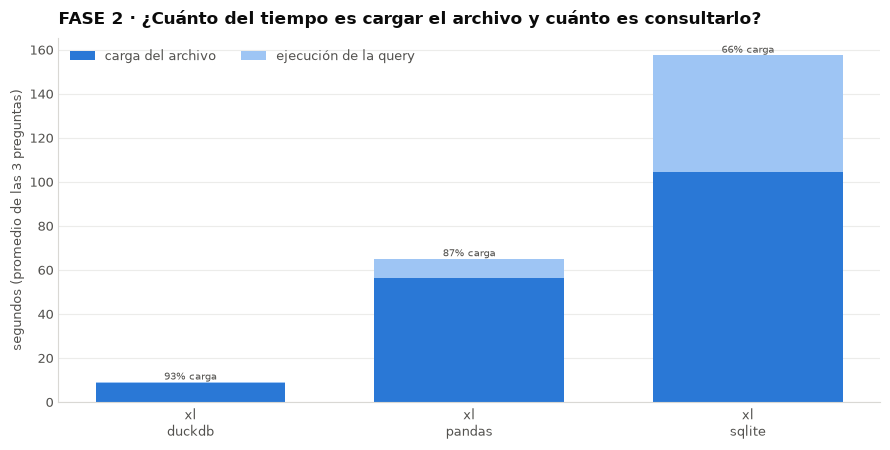

Porcentaje del tiempo que se va en cargar el archivo:
herramienta  duckdb  pandas  sqlite
version                            
xl             93.0    86.7    66.3


In [19]:
# Reparto carga vs query: ¿dónde se va el tiempo?
prom = (ok.groupby(["version", "herramienta"], observed=True)[["seg_carga", "seg_query"]]
          .mean().reset_index())
etiquetas = [f"{r.version}\n{r.herramienta}" for r in prom.itertuples()]
x = np.arange(len(prom))

fig, ax = plt.subplots(figsize=(max(9, len(prom) * 0.62), 4.6))
ax.bar(x, prom["seg_carga"], 0.68, label="carga del archivo", color="#2a78d6")
ax.bar(x, prom["seg_query"], 0.68, bottom=prom["seg_carga"],
       label="ejecución de la query", color="#9ec5f4")
for xi, (c, q) in enumerate(zip(prom["seg_carga"], prom["seg_query"])):
    ax.text(xi, c + q, f"{100*c/(c+q):.0f}% carga", ha="center", va="bottom",
            fontsize=7.5, color=TINTA2)

ax.set_xticks(x, etiquetas, fontsize=8)
ax.set_ylabel("segundos (promedio de las 3 preguntas)", color=TINTA2, fontsize=9)
ax.set_title("FASE 2 · ¿Cuánto del tiempo es cargar el archivo y cuánto es consultarlo?",
             color=TINTA, fontsize=12, fontweight="bold", loc="left", pad=10)
ax.legend(frameon=False, ncols=2, loc="upper left", labelcolor=TINTA2, fontsize=9)
estilo_ejes(ax)
ax.grid(axis="x", visible=False)
fig.tight_layout()
fig.savefig(DIR_SALIDA / f"fase2_carga_vs_query_{ETIQUETA_EQUIPO}.png", dpi=160,
            facecolor="white")
plt.show()

print("Porcentaje del tiempo que se va en cargar el archivo:")
print((prom.assign(pct_carga=(100 * prom.seg_carga / (prom.seg_carga + prom.seg_query)).round(1))
           .pivot_table(index="version", columns="herramienta", values="pct_carga",
                        observed=True)).to_string())

---
# FASE 3 - Optimizacion

## Optimizacion: preprocesar a un artefacto columnar con tipos reducidos

Un paso de ETL, ejecutado una sola vez por version, que produce artefactos optimizados sobre los cuales corren despues las consultas.

| Decision | Detalle |
|---|---|
| Parquet (pandas, duckdb) | Columnar, con projection pushdown y tipos embebidos |
| CSV estrecho de 4 columnas (sqlite) | Reduce el costo de parseo por fila |
| Proyeccion a 4 columnas | dia_semana, hora, start_station_id, end_station_id |
| Tipos reducidos (int8 / int16) | Menos memoria y mejor localidad de cache |
| Precalculo de hora y dia_semana | Se evita reparsear fechas en cada query |
| Compresion ZSTD + orden por (dia_semana, hora) | Menos bytes en disco |
| Centinela -1 en end_station_id | Permite un entero no anulable |
| Indice covering por pregunta (sqlite) | Se crea solo el indice que esa consulta necesita |

In [20]:
def rutas_opt(version):
    return (DIR_TRABAJO / f"london_{version}_opt.parquet",
            DIR_TRABAJO / f"london_{version}_opt.csv")


SQL_ETL = """
    SELECT CAST((isodow(start_rental_date_time) - 1) AS TINYINT) AS dia_semana,
           CAST(hour(start_rental_date_time)        AS TINYINT)  AS hora,
           CAST(start_station_id                    AS SMALLINT) AS start_station_id,
           CAST(COALESCE(end_station_id, -1)        AS SMALLINT) AS end_station_id
    FROM read_csv_auto('{ruta}')
    ORDER BY dia_semana, hora            -- ordenar potencia el RLE de Parquet
"""


def construir_artefactos(version, rehacer=False):
    """ETL de una versión: CSV original -> Parquet + CSV estrecho. Devuelve el registro."""
    pq, nc = rutas_opt(version)
    if pq.exists() and nc.exists() and not rehacer:
        # No se vuelve a medir, pero se recupera el tiempo de la corrida que sí los construyó,
        # para que la tabla de amortización no quede sin dato.
        previo = None
        if ruta_benchmarks().exists():
            hist = pd.read_csv(ruta_benchmarks())
            hist = hist[(hist.etapa == "etl") & (hist.version == version)
                        & (hist.equipo == ETIQUETA_EQUIPO)]
            if not hist.empty:
                previo = hist.iloc[-1].to_dict()
                REGISTRO.append(previo)
        print(f"   {version:3s} artefactos ya existen, se reutilizan "
              + (f"(ETL medido antes: {previo['seg_total']:.2f} s)" if previo
                 else "(sin medición previa del ETL; usar rehacer=True para medirlo)"))
        return previo

    ram = MuestreadorRAM(); ram.start()
    reg = {"etapa": "etl", "version": version, "equipo": ETIQUETA_EQUIPO,
           "filas_entrada": filas_por_version.get(version),
           "gb_entrada": round(RUTAS[version].stat().st_size / 1024**3, 4),
           "herramienta": "etl", "pregunta": "ETL",
           "seg_carga": None, "seg_query": None, "seg_total": None,
           "ram_pico_mb": None, "filas_salida": None, "estado": "ok", "error": None}
    con = None
    try:
        t0 = time.perf_counter()
        con = duckdb.connect()
        con.execute("CREATE OR REPLACE TABLE opt AS "
                    + SQL_ETL.format(ruta=RUTAS[version].as_posix()))
        con.execute(f"""COPY opt TO '{pq.as_posix()}'
                        (FORMAT PARQUET, COMPRESSION ZSTD, ROW_GROUP_SIZE 1000000)""")
        con.execute(f"COPY opt TO '{nc.as_posix()}' (FORMAT CSV, HEADER)")
        reg["filas_salida"] = con.execute("SELECT COUNT(*) FROM opt").fetchone()[0]
        reg["seg_total"] = reg["seg_carga"] = round(time.perf_counter() - t0, 4)
    except Exception as e:
        reg["estado"], reg["error"] = "ERROR", f"{type(e).__name__}: {e}"
    finally:
        if con is not None:
            con.close()
        gc.collect()
        reg["ram_pico_mb"] = round(ram.detener(), 1)

    REGISTRO.append(reg)
    if reg["estado"] == "ok":
        print(f"   {version:3s} ETL {reg['seg_total']:8.2f} s | "
              f"CSV {reg['gb_entrada']*1024:8,.0f} MB -> "
              f"parquet {pq.stat().st_size/1024**2:8,.1f} MB + "
              f"csv estrecho {nc.stat().st_size/1024**2:8,.1f} MB")
    else:
        print(f"   {version:3s} ETL FALLÓ: {reg['error'][:160]}")
    return reg


print("ETL — construcción de los artefactos optimizados")
for v in VERSIONES:
    construir_artefactos(v)
guardar_registro()

VERSIONES_OPT = [v for v in VERSIONES if all(p.exists() for p in rutas_opt(v))]
print()
print(f"Versiones con artefactos listos: {', '.join(VERSIONES_OPT)}")

ETL — construcción de los artefactos optimizados
   xl  ETL     6.30 s | CSV    4,839 MB -> parquet     91.5 MB + csv estrecho    453.1 MB

Versiones con artefactos listos: xl


In [21]:
# Reducción de tamaño en disco
filas_tam = []
for v in VERSIONES_OPT:
    pq, nc = rutas_opt(v)
    filas_tam.append({
        "version": v,
        "csv_original_mb": round(RUTAS[v].stat().st_size / 1024**2, 1),
        "parquet_mb":      round(pq.stat().st_size / 1024**2, 1),
        "csv_estrecho_mb": round(nc.stat().st_size / 1024**2, 1),
    })
tam = pd.DataFrame(filas_tam).set_index("version")
tam["reduccion_parquet_x"] = (tam.csv_original_mb / tam.parquet_mb).round(1)
tam["reduccion_csv_x"]     = (tam.csv_original_mb / tam.csv_estrecho_mb).round(1)
print("TAMAÑO EN DISCO DE LOS ARTEFACTOS")
print(tam.to_string())

TAMAÑO EN DISCO DE LOS ARTEFACTOS
         csv_original_mb  parquet_mb  csv_estrecho_mb  reduccion_parquet_x  reduccion_csv_x
version                                                                                    
xl                4838.6        91.5            453.1                 52.9             10.7


### Implementaciones optimizadas

Misma interfaz que las de la FASE 2.

In [22]:
COLS_OPT = ["dia_semana", "hora", "start_station_id", "end_station_id"]


# ---------------------------------------------------------------- pandas-opt
def pd_opt_cargar(ruta, pregunta=None):
    return pd.read_parquet(ruta, columns=COLS_OPT)


def pd_opt_q1(df):
    return (df.groupby(["dia_semana", "hora"]).size().rename("viajes").reset_index()
              .sort_values(["dia_semana", "hora"], ignore_index=True))


def pd_opt_q2(df):
    salidas  = df["start_station_id"].value_counts().rename("salidas")
    llegadas = (df.loc[df["end_station_id"] >= 0, "end_station_id"]
                  .value_counts().rename("llegadas"))
    q2 = pd.concat([salidas, llegadas], axis=1).fillna(0).astype("int64")
    q2.index.name = "station_id"
    q2 = q2.reset_index()
    q2["neto"]  = q2["llegadas"] - q2["salidas"]
    q2["total"] = q2["llegadas"] + q2["salidas"]
    q2["desequilibrio_pct"] = (q2["neto"] / q2["total"].replace(0, np.nan) * 100).round(2)
    return q2.sort_values(["neto", "station_id"], ignore_index=True)


def pd_opt_q3(df):
    q3 = (df[df["end_station_id"] >= 0]
            .groupby(["start_station_id", "end_station_id"]).size()
            .rename("viajes").reset_index()
            .sort_values(["viajes", "start_station_id", "end_station_id"],
                         ascending=[False, True, True], ignore_index=True))
    total = int(q3["viajes"].sum())
    q3["pct"]      = q3["viajes"] / total * 100
    q3["pct_acum"] = q3["pct"].cumsum()
    return q3


# ---------------------------------------------------------------- duckdb-opt
SQL_DK_OPT = {
    "Q1": """SELECT dia_semana, hora, COUNT(*) AS viajes
             FROM viajes_opt GROUP BY 1, 2 ORDER BY 1, 2""",
    "Q2": """WITH s AS (SELECT start_station_id AS station_id, COUNT(*) AS salidas
                        FROM viajes_opt GROUP BY 1),
                  l AS (SELECT end_station_id AS station_id, COUNT(*) AS llegadas
                        FROM viajes_opt WHERE end_station_id >= 0 GROUP BY 1),
                  ids AS (SELECT station_id FROM s UNION SELECT station_id FROM l)
             SELECT ids.station_id,
                    COALESCE(s.salidas, 0), COALESCE(l.llegadas, 0),
                    COALESCE(l.llegadas, 0) - COALESCE(s.salidas, 0) AS neto,
                    COALESCE(l.llegadas, 0) + COALESCE(s.salidas, 0),
                    ROUND(100.0 * (COALESCE(l.llegadas, 0) - COALESCE(s.salidas, 0))
                          / NULLIF(COALESCE(l.llegadas, 0) + COALESCE(s.salidas, 0), 0), 2)
             FROM ids LEFT JOIN s ON s.station_id = ids.station_id
                      LEFT JOIN l ON l.station_id = ids.station_id
             ORDER BY neto, ids.station_id""",
    "Q3": """WITH pares AS (SELECT start_station_id, end_station_id, COUNT(*) AS viajes
                            FROM viajes_opt WHERE end_station_id >= 0 GROUP BY 1, 2)
             SELECT start_station_id, end_station_id, viajes,
                    100.0 * viajes / SUM(viajes) OVER (),
                    100.0 * SUM(viajes) OVER (ORDER BY viajes DESC,
                                                       start_station_id, end_station_id
                                              ROWS UNBOUNDED PRECEDING)
                          / SUM(viajes) OVER ()
             FROM pares ORDER BY viajes DESC, start_station_id, end_station_id""",
}


def dk_opt_cargar(ruta, pregunta=None):
    con = duckdb.connect()
    con.execute(f"""CREATE TABLE viajes_opt AS
                    SELECT * FROM read_parquet('{ruta.as_posix()}')""")
    return con


# ---------------------------------------------------------------- sqlite-opt
DDL_OPT = """
CREATE TABLE viajes_opt (
    dia_semana       INTEGER,
    hora             INTEGER,
    start_station_id INTEGER,
    end_station_id   INTEGER
)
"""

# Solo el índice que cubre la pregunta que se va a ejecutar: en este protocolo la base
# se reconstruye en cada ejecución, así que crear índices de más es puro costo.
INDICES_OPT = {
    "Q1": ["CREATE INDEX ix_q1 ON viajes_opt(dia_semana, hora)"],
    "Q2": ["CREATE INDEX ix_q2a ON viajes_opt(start_station_id)",
           "CREATE INDEX ix_q2b ON viajes_opt(end_station_id)"],
    "Q3": ["CREATE INDEX ix_q3 ON viajes_opt(start_station_id, end_station_id)"],
}

SQL_LT_OPT = {
    "Q1": """SELECT dia_semana, hora, COUNT(*) AS viajes
             FROM viajes_opt GROUP BY 1, 2 ORDER BY 1, 2""",
    "Q2": SQL_DK_OPT["Q2"],
    "Q3": """WITH pares AS (SELECT start_station_id, end_station_id, COUNT(*) AS viajes
                            FROM viajes_opt WHERE end_station_id >= 0 GROUP BY 1, 2),
                  tot AS (SELECT SUM(viajes) AS n FROM pares)
             SELECT start_station_id, end_station_id, viajes,
                    100.0 * viajes / (SELECT n FROM tot),
                    100.0 * SUM(viajes) OVER (ORDER BY viajes DESC,
                                                       start_station_id, end_station_id
                                              ROWS UNBOUNDED PRECEDING)
                          / (SELECT n FROM tot)
             FROM pares ORDER BY viajes DESC, start_station_id, end_station_id""",
}


def lt_opt_cargar(ruta, pregunta=None):
    base = BaseSQLite(DIR_TRABAJO / f"tmpopt_{os.getpid()}_{time.time_ns()}.db")
    for p in PRAGMAS_CARGA:
        base.con.execute(p)
    base.con.execute(DDL_OPT)
    _ingestar_csv(base, ruta, "INSERT INTO viajes_opt VALUES (?,?,?,?)", 4)
    for ddl in INDICES_OPT.get(pregunta, []):
        base.con.execute(ddl)
    base.con.execute("ANALYZE")
    base.con.commit()
    return base


IMPL_OPT = {
    "pandas-opt": {"ruta": lambda v: rutas_opt(v)[0],
                   "cargar": pd_opt_cargar, "liberar": pd_liberar,
                   "Q1": pd_opt_q1, "Q2": pd_opt_q2, "Q3": pd_opt_q3},
    "duckdb-opt": {"ruta": lambda v: rutas_opt(v)[0],
                   "cargar": dk_opt_cargar, "liberar": dk_liberar,
                   "Q1": lambda c: dk_consulta(c, "Q1", SQL_DK_OPT),
                   "Q2": lambda c: dk_consulta(c, "Q2", SQL_DK_OPT),
                   "Q3": lambda c: dk_consulta(c, "Q3", SQL_DK_OPT)},
    "sqlite-opt": {"ruta": lambda v: rutas_opt(v)[1],
                   "cargar": lt_opt_cargar, "liberar": lt_liberar,
                   "Q1": lambda b: lt_consulta(b, "Q1", SQL_LT_OPT),
                   "Q2": lambda b: lt_consulta(b, "Q2", SQL_LT_OPT),
                   "Q3": lambda b: lt_consulta(b, "Q3", SQL_LT_OPT)},
}

# Verificación del plan: la query de Q1 debe resolverse con un COVERING INDEX
_b = lt_opt_cargar(rutas_opt(VERSIONES_OPT[0])[1], "Q1")
print("Plan de ejecución de Q1 en sqlite-opt:")
for fila in _b.con.execute("EXPLAIN QUERY PLAN " + SQL_LT_OPT["Q1"]).fetchall():
    print("   ", fila[-1])
_b.cerrar(); del _b; gc.collect()

Plan de ejecución de Q1 en sqlite-opt:
    SCAN viajes_opt USING COVERING INDEX ix_q1


0

### Barrido optimizado

In [23]:
barrer("optimizado", VERSIONES_OPT, IMPL_OPT)


VERSIÓN 'xl'  —  london.csv  (38,215,560 filas)
   pandas-opt Q1  carga      0.30 s + query      1.20 s =      1.50 s   RAM pico    3,966 MB   [ok]
   pandas-opt Q2  carga      0.13 s + query      0.39 s =      0.52 s   RAM pico    3,651 MB   [ok]
   pandas-opt Q3  carga      0.11 s + query      1.31 s =      1.42 s   RAM pico    3,601 MB   [ok]
   duckdb-opt Q1  carga      0.29 s + query      0.04 s =      0.32 s   RAM pico    3,584 MB   [ok]
   duckdb-opt Q2  carga      0.30 s + query      0.08 s =      0.37 s   RAM pico    3,529 MB   [ok]
   duckdb-opt Q3  carga      0.38 s + query      1.62 s =      2.01 s   RAM pico    3,143 MB   [ok]
   sqlite-opt Q1  carga     64.39 s + query      2.08 s =     66.47 s   RAM pico    2,779 MB   [ok]
   sqlite-opt Q2  carga    129.28 s + query      3.00 s =    132.28 s   RAM pico    1,711 MB   [ok]
   sqlite-opt Q3  carga     89.63 s + query      3.14 s =     92.77 s   RAM pico    1,855 MB   [ok]

Barrido 'optimizado' terminado en 5.0 min. Registr

### Validacion: la optimizacion no cambio las respuestas

In [24]:
print("VALIDACIÓN — etapa 'optimizado' contra la línea base")
for v in VERSIONES_OPT:
    for preg in PREGUNTAS:
        ref = None
        for h in IMPL_BASE:
            ref = RESULTADOS.get(("base", v, h, preg))
            if ref is not None:
                break
        if ref is None:
            print(f"   {v:3s} {preg}: la línea base no completó, no hay con qué comparar")
            continue
        ref = ref.sort_values(CLAVES[preg], ignore_index=True)
        col = "neto" if preg == "Q2" else "viajes"
        for h in IMPL_OPT:
            otro = RESULTADOS.get(("optimizado", v, h, preg))
            if otro is None:
                print(f"   {v:3s} {preg} {h:11s} -> no completó")
                continue
            otro = otro.sort_values(CLAVES[preg], ignore_index=True)
            igual = (len(ref) == len(otro)
                     and ref[col].astype("int64").equals(otro[col].astype("int64")))
            print(f"   {v:3s} {preg} {h:11s} -> {'IDÉNTICO' if igual else 'DIFIERE'}")

VALIDACIÓN — etapa 'optimizado' contra la línea base
   xl  Q1 pandas-opt  -> IDÉNTICO
   xl  Q1 duckdb-opt  -> IDÉNTICO
   xl  Q1 sqlite-opt  -> IDÉNTICO
   xl  Q2 pandas-opt  -> IDÉNTICO
   xl  Q2 duckdb-opt  -> IDÉNTICO
   xl  Q2 sqlite-opt  -> IDÉNTICO
   xl  Q3 pandas-opt  -> IDÉNTICO
   xl  Q3 duckdb-opt  -> IDÉNTICO
   xl  Q3 sqlite-opt  -> IDÉNTICO


### Impacto de la optimizacion

In [25]:
todo = cargar_bench(["base", "optimizado", "etl"])
PARES = [("pandas", "pandas-opt"), ("duckdb", "duckdb-opt"), ("sqlite", "sqlite-opt")]

piv = todo.pivot_table(index=["version", "pregunta"], columns="herramienta",
                       values="seg_total", aggfunc="last", observed=True)

comp = pd.DataFrame(index=piv.index)
for a, b in PARES:
    if a in piv.columns and b in piv.columns:
        comp[f"{a} antes"]   = piv[a].round(2)
        comp[f"{a} después"] = piv[b].round(2)
        comp[f"{a} ×"]       = (piv[a] / piv[b]).round(1)
print("TIEMPO TOTAL (carga + query) — antes vs después, en segundos")
print(comp.to_string())

etl = todo[todo.etapa == "etl"].set_index("version")["seg_total"]
resumen = []
for v in VERSIONES_OPT:
    sub = piv.loc[v]
    for a, b in PARES:
        if a not in sub or b not in sub:
            continue
        antes, despues = sub[a].sum(), sub[b].sum()
        if pd.isna(antes) or pd.isna(despues):
            continue
        ahorro = antes - despues
        resumen.append({
            "version": v, "herramienta": a,
            "antes_s": round(antes, 2), "despues_s": round(despues, 2),
            "mejora_x": round(antes / despues, 1),
            "ahorro_s": round(ahorro, 2),
            "etl_s": round(float(etl.get(v, np.nan)), 2),
            "corridas_para_amortizar": (round(float(etl.get(v, np.nan)) / ahorro, 2)
                                        if ahorro > 0 else np.inf),
        })
resumen = pd.DataFrame(resumen)
print()
print("RESUMEN POR VERSIÓN (suma de las 3 preguntas) Y AMORTIZACIÓN DEL ETL")
print(resumen.to_string(index=False))

TIEMPO TOTAL (carga + query) — antes vs después, en segundos
                  pandas antes  pandas después  pandas ×  duckdb antes  duckdb después  duckdb ×  sqlite antes  sqlite después  sqlite ×
version pregunta                                                                                                                        
xl      ETL                NaN             NaN       NaN           NaN             NaN       NaN           NaN             NaN       NaN
        Q1               59.45            1.50      39.7          9.30            0.32      28.6        128.42           66.47       1.9
        Q2               57.13            0.52     109.7          8.42            0.37      22.5        191.47          132.28       1.4
        Q3               78.79            1.42      55.4          9.59            2.01       4.8        152.75           92.77       1.6

RESUMEN POR VERSIÓN (suma de las 3 preguntas) Y AMORTIZACIÓN DEL ETL
version herramienta  antes_s  despues_s  mejora

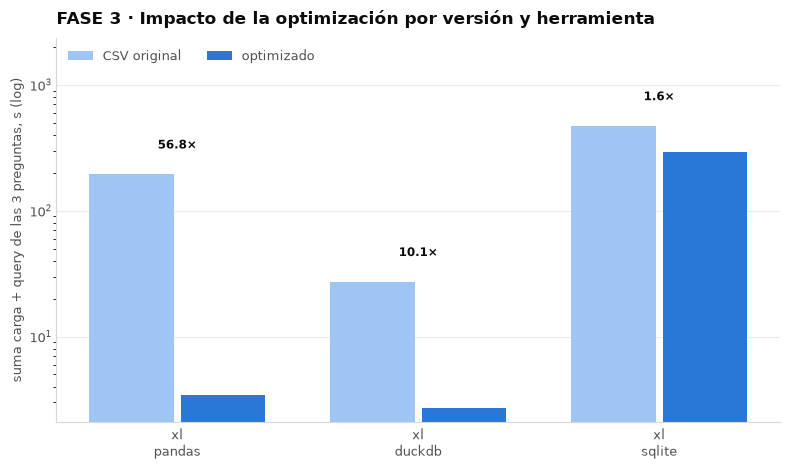

In [27]:
ok_t = todo[(todo.estado.isin(["ok", "EXCEDE"])) & (todo.etapa != "etl")]
agg = (ok_t.groupby(["version", "herramienta"], observed=True)["seg_total"]
            .sum().reset_index())


def total(version, herramienta):
    s = agg.loc[(agg.version == version) & (agg.herramienta == herramienta), "seg_total"]
    return float(s.sum()) if len(s) else np.nan


# Un par de barras por combinación (versión, herramienta): así la etiqueta de cada
# herramienta vive en el eje x y no encima de las barras.
combos  = [(v, a, b) for v in VERSIONES_OPT for a, b in PARES]
antes   = [total(v, a) for v, a, _ in combos]
despues = [total(v, b) for v, _, b in combos]
x       = np.arange(len(combos))
ancho   = 0.38

fig, ax = plt.subplots(figsize=(max(8, len(combos) * 0.95), 4.8))
ax.set_yscale("log")
ax.bar(x - ancho/2, antes,   ancho * 0.92, color="#9ec5f4", label="CSV original")
ax.bar(x + ancho/2, despues, ancho * 0.92, color="#2a78d6", label="optimizado")
for xi, (a_, b_) in enumerate(zip(antes, despues)):
    if a_ > 0 and b_ > 0:
        ax.text(xi, max(a_, b_) * 1.6, f"{a_/b_:.1f}×", ha="center", fontsize=8.5,
                color=TINTA, fontweight="bold", path_effects=HALO)

ax.set_ylim(top=float(np.nanmax(antes)) * 5)
ax.set_xticks(x, [v + "\n" + a for v, a, _ in combos], fontsize=8.5)
ax.set_ylabel("suma carga + query de las 3 preguntas, s (log)", color=TINTA2, fontsize=9)
ax.set_title("FASE 3 · Impacto de la optimización por versión y herramienta",
             color=TINTA, fontsize=12, fontweight="bold", loc="left", pad=10)
ax.legend(frameon=False, ncols=2, loc="upper left", labelcolor=TINTA2, fontsize=9)
estilo_ejes(ax)
ax.grid(axis="x", visible=False)
fig.tight_layout()
fig.savefig(DIR_SALIDA / f"fase3_impacto_{ETIQUETA_EQUIPO}.png", dpi=160, facecolor="white")
plt.show()

### Punto de extension

Para agregar otra optimizacion:

1. Escribir `cargar(ruta, pregunta)` y `Q1/Q2/Q3(obj)`.
2. Armar el diccionario con la misma forma que `IMPL_BASE` / `IMPL_OPT`.
3. Llamar a `barrer("mi_etapa", VERSIONES, MI_IMPL)`.

---
## 7. Respuestas a las 3 preguntas

Se usa la version mas grande que haya completado, con los DataFrames ya calculados.

In [29]:
def respuesta(pregunta, version=None):
    """Devuelve el resultado de una pregunta en la versión indicada (o V_RESPUESTAS)."""
    version = version or V_RESPUESTAS
    for etapa in ("base", "optimizado"):
        for herr in list(IMPL_BASE) + list(IMPL_OPT):
            r = RESULTADOS.get((etapa, version, herr, pregunta))
            if r is not None:
                return r
    raise KeyError(f"No hay resultado para {pregunta} en la versión '{version}'")


V_RESP = V_RESPUESTAS
q1 = respuesta("Q1"); q2 = respuesta("Q2"); q3 = respuesta("Q3")
print(f"Respondiendo con la versión '{V_RESP}' — "
      f"{filas_por_version[V_RESP]:,} viajes, archivo {NOMBRES[V_RESP]}")
print(f"   Q1: {len(q1):,} combinaciones día×hora")
print(f"   Q2: {len(q2):,} estaciones con actividad")
print(f"   Q3: {len(q3):,} rutas origen-destino distintas")

Respondiendo con la versión 'xl' — 38,215,560 viajes, archivo london.csv
   Q1: 168 combinaciones día×hora
   Q2: 808 estaciones con actividad
   Q3: 510,672 rutas origen-destino distintas


### Q1 - Demanda por hora del dia y dia de la semana

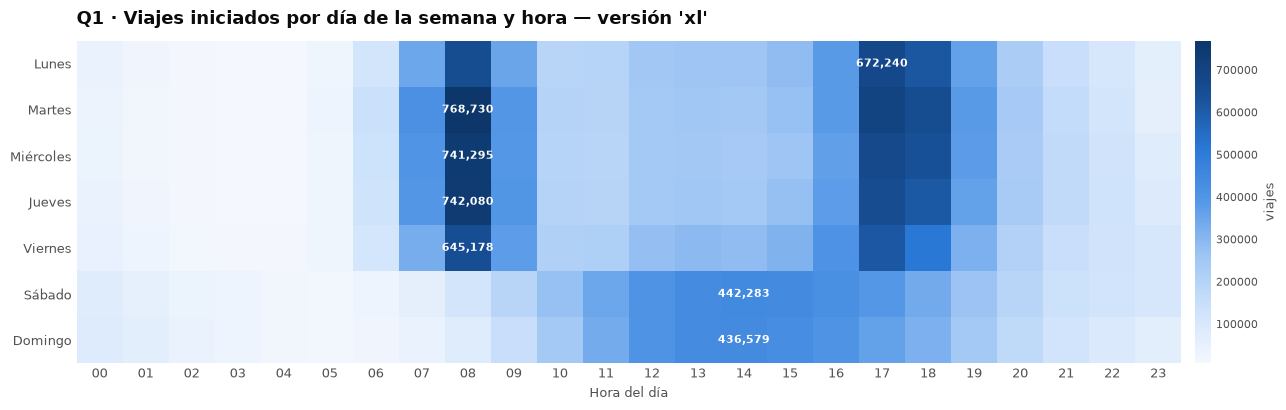

Hora pico de cada día:
   Lunes      17:00 h  con      672,240 viajes  | total del día:      5,590,150
   Martes     08:00 h  con      768,730 viajes  | total del día:      5,902,367
   Miércoles  08:00 h  con      741,295 viajes  | total del día:      5,795,257
   Jueves     08:00 h  con      742,080 viajes  | total del día:      5,795,656
   Viernes    08:00 h  con      645,178 viajes  | total del día:      5,633,146
   Sábado     14:00 h  con      442,283 viajes  | total del día:      4,914,592
   Domingo    14:00 h  con      436,579 viajes  | total del día:      4,584,392


In [30]:
matriz = (q1.pivot(index="dia_semana", columns="hora", values="viajes")
            .reindex(index=range(7), columns=range(24)).fillna(0))

# Escala secuencial de un solo tono (claro -> oscuro): codifica magnitud, no identidad
RAMPA_AZUL = LinearSegmentedColormap.from_list(
    "azul", ["#f4f8fe", "#cde2fb", "#9ec5f4", "#5598e7", "#2a78d6", "#184f95", "#0d366b"])

fig, ax = plt.subplots(figsize=(13, 4.2))
im = ax.imshow(matriz.to_numpy(), cmap=RAMPA_AZUL, aspect="auto")
ax.set_xticks(range(24), [f"{h:02d}" for h in range(24)])
ax.set_yticks(range(7), DIAS)
ax.tick_params(colors=TINTA2, labelsize=9, length=0)
for s in ax.spines.values():
    s.set_visible(False)
ax.set_xlabel("Hora del día", color=TINTA2, fontsize=9)
ax.set_title(f"Q1 · Viajes iniciados por día de la semana y hora — versión '{V_RESP}'",
             color=TINTA, fontsize=13, fontweight="bold", loc="left", pad=12)

# Etiqueta directa solo en la celda pico de cada día (no un número en cada celda)
_max = matriz.to_numpy().max()
for d in range(7):
    h_pico = int(matriz.loc[d].idxmax())
    v = matriz.loc[d, h_pico]
    ax.text(h_pico, d, f"{v:,.0f}", ha="center", va="center", fontsize=8,
            fontweight="bold", color="white" if v > _max * 0.55 else TINTA)

cb = fig.colorbar(im, ax=ax, pad=0.012, fraction=0.025)
cb.set_label("viajes", color=TINTA2, fontsize=9)
cb.ax.tick_params(colors=TINTA2, labelsize=8, length=0)
cb.outline.set_visible(False)
fig.tight_layout()
fig.savefig(DIR_SALIDA / f"q1_heatmap_{V_RESP}.png", dpi=160, facecolor="white")
plt.show()

print("Hora pico de cada día:")
for d in range(7):
    h = int(matriz.loc[d].idxmax())
    print(f"   {DIAS[d]:10s} {h:02d}:00 h  con {matriz.loc[d, h]:12,.0f} viajes  "
          f"| total del día: {matriz.loc[d].sum():14,.0f}")

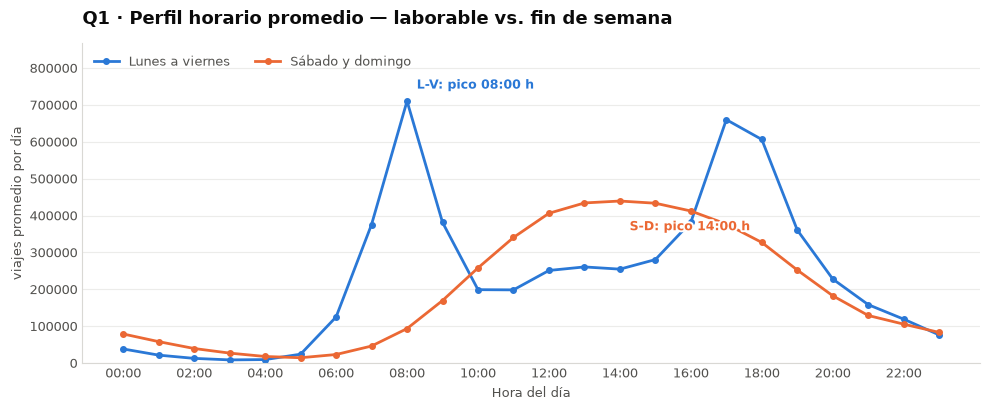

Laborables — 2 horas pico : ['08:00', '17:00']
Fin de semana — hora pico : 14:00
Ratio pico laborable / pico fin de semana: 1.62×
Viajes en horas valle (00-05 h): 2.7% del total


In [31]:
# Perfil horario: laborable vs. fin de semana (2 series -> paleta categórica, con leyenda)
lab = matriz.loc[0:4].mean(axis=0)
fds = matriz.loc[5:6].mean(axis=0)

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(lab.index, lab.to_numpy(), linewidth=2, color="#2a78d6",
        marker="o", markersize=4, label="Lunes a viernes")
ax.plot(fds.index, fds.to_numpy(), linewidth=2, color="#eb6834",
        marker="o", markersize=4, label="Sábado y domingo")

# El pico de L-V se etiqueta arriba y el de S-D abajo: justo encima del máximo de S-D
# pasa la curva de L-V y las dos etiquetas se pisarían.
for serie, color, nombre, dy in [(lab, "#2a78d6", "L-V", 9), (fds, "#eb6834", "S-D", -21)]:
    hp = int(serie.idxmax())
    ax.annotate(f"{nombre}: pico {hp:02d}:00 h", xy=(hp, serie[hp]),
                xytext=(7, dy), textcoords="offset points",
                fontsize=9, color=color, fontweight="bold", path_effects=HALO)

ax.set_ylim(0, float(max(lab.max(), fds.max())) * 1.22)
ax.set_xticks(range(0, 24, 2), [f"{h:02d}:00" for h in range(0, 24, 2)])
ax.set_xlabel("Hora del día", color=TINTA2, fontsize=9)
ax.set_ylabel("viajes promedio por día", color=TINTA2, fontsize=9)
ax.set_title("Q1 · Perfil horario promedio — laborable vs. fin de semana",
             color=TINTA, fontsize=13, fontweight="bold", loc="left", pad=14)
ax.legend(frameon=False, ncols=2, loc="upper left", labelcolor=TINTA2, fontsize=9)
estilo_ejes(ax)
ax.grid(axis="x", visible=False)
fig.tight_layout()
fig.savefig(DIR_SALIDA / f"q1_perfil_horario_{V_RESP}.png", dpi=160, facecolor="white")
plt.show()

print(f"Laborables — 2 horas pico : "
      f"{[f'{h:02d}:00' for h in sorted(lab.nlargest(2).index.tolist())]}")
print(f"Fin de semana — hora pico : {int(fds.idxmax()):02d}:00")
print(f"Ratio pico laborable / pico fin de semana: {lab.max()/fds.max():.2f}×")
print(f"Viajes en horas valle (00-05 h): "
      f"{100*matriz.loc[:, 0:5].to_numpy().sum()/matriz.to_numpy().sum():.1f}% del total")

### Q2 - Estaciones con mayor desequilibrio entre llegadas y salidas

`neto = llegadas - salidas`. Negativo: la estacion se vacia. Positivo: la estacion se satura.

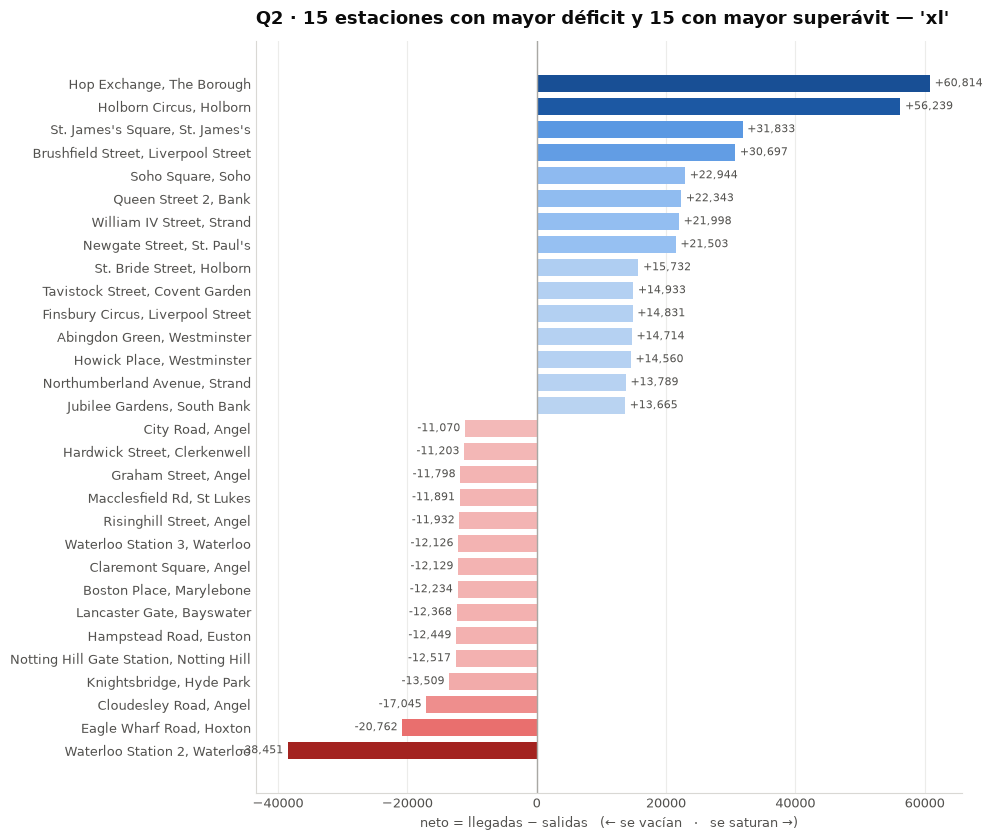

TOP 10 DÉFICIT — hay que llevarles bicicletas:
 station_id                            station_name  salidas  llegadas   neto  desequilibrio_pct
        361            Waterloo Station 2, Waterloo   125584     87133 -38451             -18.08
        574                Eagle Wharf Road, Hoxton   107628     86866 -20762             -10.67
         93                  Cloudesley Road, Angel    43919     26874 -17045             -24.08
        222                Knightsbridge, Hyde Park    51202     37693 -13509             -15.20
        225 Notting Hill Gate Station, Notting Hill    89800     77283 -12517              -7.49
         98                  Hampstead Road, Euston    64964     52515 -12449             -10.60
        524               Lancaster Gate, Bayswater    56453     44085 -12368             -12.30
         45                Boston Place, Marylebone    77852     65618 -12234              -8.53
        189                 Claremont Square, Angel    32866     20737 -12129   

In [32]:
q2_nom = (q2.merge(estaciones, on="station_id", how="left")
            .assign(station_name=lambda d: d["station_name"]
                    .fillna("(estación " + d["station_id"].astype(str) + ")")))

deficit   = q2_nom.nsmallest(15, "neto").sort_values("neto")
superavit = q2_nom.nlargest(15, "neto").sort_values("neto")
extremos  = pd.concat([deficit, superavit])

# Escala divergente: dos tonos opuestos con gris neutro en el cero (polaridad, no magnitud)
RAMPA_DIV = LinearSegmentedColormap.from_list(
    "div", ["#a32320", "#e34948", "#f3b0af", "#f0efec", "#9ec5f4", "#2a78d6", "#184f95"])
norma = TwoSlopeNorm(vmin=min(extremos["neto"].min(), -1), vcenter=0,
                     vmax=max(extremos["neto"].max(), 1))

fig, ax = plt.subplots(figsize=(10, 8.5))
y = np.arange(len(extremos))
ax.barh(y, extremos["neto"], color=RAMPA_DIV(norma(extremos["neto"])), height=0.74)
ax.axvline(0, color="#a9a8a4", linewidth=1)
dx = 0.012 * max(abs(extremos["neto"].min()), extremos["neto"].max())
for yi, n in enumerate(extremos["neto"]):
    ax.text(n + (dx if n >= 0 else -dx), yi, f"{n:+,}", va="center",
            ha="left" if n >= 0 else "right", fontsize=8, color=TINTA2)

ax.set_yticks(y, [s[:44] for s in extremos["station_name"]])
ax.tick_params(axis="y", labelsize=8)
ax.set_xlabel("neto = llegadas − salidas   (← se vacían   ·   se saturan →)",
              color=TINTA2, fontsize=9)
ax.set_title(f"Q2 · 15 estaciones con mayor déficit y 15 con mayor superávit — '{V_RESP}'",
             color=TINTA, fontsize=13, fontweight="bold", loc="left", pad=12)
estilo_ejes(ax)
ax.grid(axis="y", visible=False)
fig.tight_layout()
fig.savefig(DIR_SALIDA / f"q2_desequilibrio_{V_RESP}.png", dpi=160, facecolor="white")
plt.show()

COLS_Q2 = ["station_id", "station_name", "salidas", "llegadas", "neto", "desequilibrio_pct"]
print("TOP 10 DÉFICIT — hay que llevarles bicicletas:")
print(deficit.head(10)[COLS_Q2].to_string(index=False))
print()
print("TOP 10 SUPERÁVIT — hay que retirarles bicicletas:")
print(superavit.tail(10).iloc[::-1][COLS_Q2].to_string(index=False))
print()
print("TOP 10 por desequilibrio RELATIVO (mín. 500 viajes de actividad):")
print(q2_nom[q2_nom.total >= 500].nsmallest(10, "desequilibrio_pct")[COLS_Q2]
      .to_string(index=False))

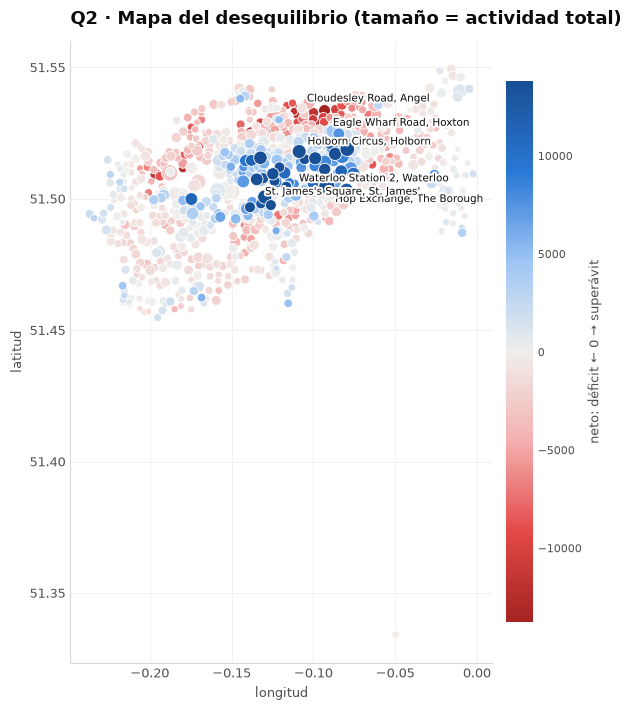

In [33]:
# Mapa: posición geográfica, color = desequilibrio neto, tamaño = actividad total
mapa = q2_nom.dropna(subset=["latitude", "longitude"])
lim  = float(np.abs(mapa["neto"]).quantile(0.98)) or 1.0
norma_mapa = TwoSlopeNorm(vmin=-lim, vcenter=0, vmax=lim)

fig, ax = plt.subplots(figsize=(10, 7.2))
sc = ax.scatter(mapa["longitude"], mapa["latitude"],
                c=mapa["neto"].clip(-lim, lim), cmap=RAMPA_DIV, norm=norma_mapa,
                s=18 + 170 * mapa["total"] / mapa["total"].max(),
                edgecolors="white", linewidths=0.6)

# Solo 3 extremos por lado: con más etiquetas se pisan sobre un mapa denso.
# El nombre completo de las 30 estaciones está en el gráfico de barras anterior.
for i, (_, r) in enumerate(pd.concat([mapa.nsmallest(3, "neto"),
                                      mapa.nlargest(3, "neto")]).iterrows()):
    ax.annotate(str(r["station_name"])[:30], (r["longitude"], r["latitude"]),
                xytext=(6, 5 if i % 2 == 0 else -11), textcoords="offset points",
                fontsize=7.5, color=TINTA, path_effects=HALO)

ax.set_xlabel("longitud", color=TINTA2, fontsize=9)
ax.set_ylabel("latitud", color=TINTA2, fontsize=9)
ax.set_aspect(1 / np.cos(np.radians(float(mapa["latitude"].mean()))))
ax.set_title("Q2 · Mapa del desequilibrio (tamaño = actividad total)",
             color=TINTA, fontsize=13, fontweight="bold", loc="left", pad=12)
cb = fig.colorbar(sc, ax=ax, pad=0.015, fraction=0.03)
cb.set_label("neto: déficit ← 0 → superávit", color=TINTA2, fontsize=9)
cb.ax.tick_params(colors=TINTA2, labelsize=8, length=0)
cb.outline.set_visible(False)
estilo_ejes(ax)
ax.grid(color="#f2f1ef", linewidth=0.7)
fig.tight_layout()
fig.savefig(DIR_SALIDA / f"q2_mapa_{V_RESP}.png", dpi=160, facecolor="white")
plt.show()

### Q3 - Rutas origen-destino que concentran trafico

In [34]:
nombres = estaciones.set_index("station_id")["station_name"]

q3_nom = q3.head(TOP_N).copy()
q3_nom["origen"]     = q3_nom["start_station_id"].map(nombres).fillna("?")
q3_nom["destino"]    = q3_nom["end_station_id"].map(nombres).fillna("?")
q3_nom["ruta"]       = (q3_nom["origen"].str.slice(0, 30) + "  →  "
                        + q3_nom["destino"].str.slice(0, 30))
q3_nom["ida_vuelta"] = np.where(
    q3_nom["start_station_id"] == q3_nom["end_station_id"], "sí (circular)", "")

print(f"TOP {TOP_N} RUTAS — versión '{V_RESP}'")
print(q3_nom[["ruta", "viajes", "pct", "pct_acum", "ida_vuelta"]]
      .round({"pct": 3, "pct_acum": 2}).to_string(index=False))

TOP 20 RUTAS — versión 'xl'
                                                             ruta  viajes   pct  pct_acum    ida_vuelta
      Hyde Park Corner, Hyde Park  →  Hyde Park Corner, Hyde Park   72625 0.190      0.19 sí (circular)
Aquatic Centre, Queen Elizabet  →  Aquatic Centre, Queen Elizabet   67661 0.177      0.37 sí (circular)
                Albert Gate, Hyde Park  →  Albert Gate, Hyde Park   42049 0.110      0.48 sí (circular)
Black Lion Gate, Kensington Ga  →  Black Lion Gate, Kensington Ga   40221 0.105      0.58 sí (circular)
    Triangle Car Park, Hyde Park  →  Triangle Car Park, Hyde Park   35652 0.093      0.68 sí (circular)
                    Park Lane, Hyde Park  →  Park Lane, Hyde Park   35438 0.093      0.77 sí (circular)
Podium, Queen Elizabeth Olympi  →  Podium, Queen Elizabeth Olympi   23977 0.063      0.83 sí (circular)
Palace Gate, Kensington Garden  →  Palace Gate, Kensington Garden   20312 0.053      0.89 sí (circular)
        Wellington Arch, Hyde Park  

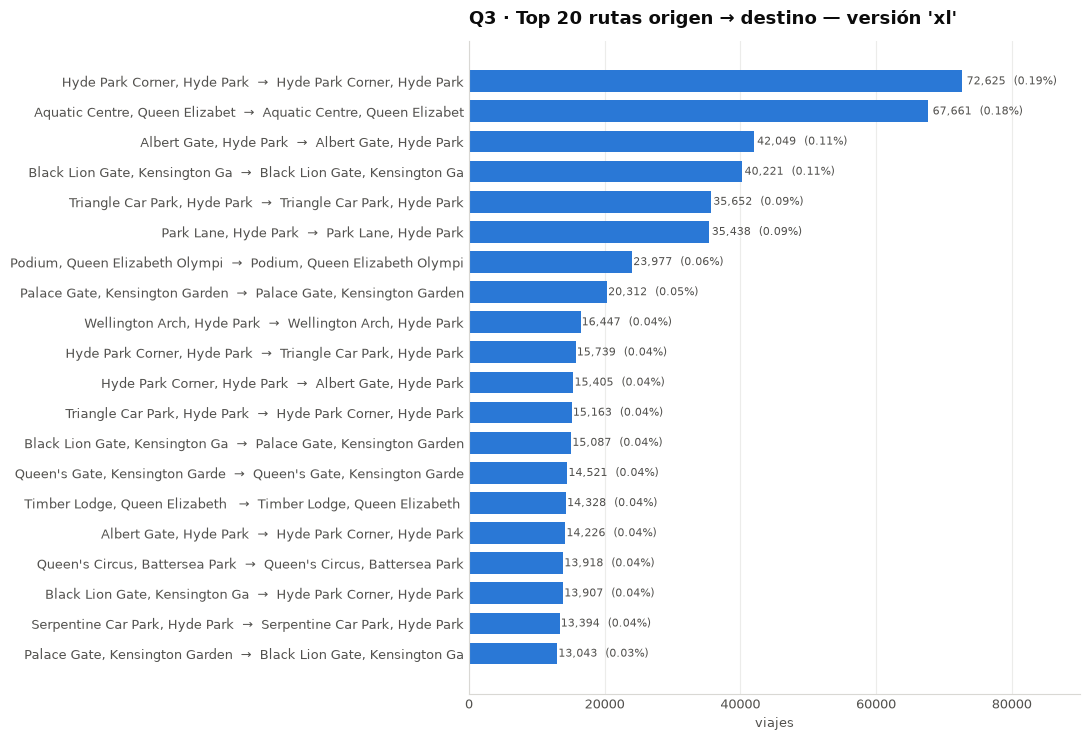

In [35]:
top = q3_nom.iloc[::-1]     # la ruta más usada arriba

fig, ax = plt.subplots(figsize=(11, 7.5))
ax.barh(np.arange(len(top)), top["viajes"], color="#2a78d6", height=0.72)
for yi, (v, p) in enumerate(zip(top["viajes"], top["pct"])):
    ax.text(v * 1.01, yi, f"{v:,}  ({p:.2f}%)", va="center", fontsize=8, color=TINTA2)

ax.set_yticks(np.arange(len(top)), top["ruta"])
ax.tick_params(axis="y", labelsize=8)
ax.set_xlabel("viajes", color=TINTA2, fontsize=9)
ax.set_xlim(0, top["viajes"].max() * 1.24)
ax.set_title(f"Q3 · Top {TOP_N} rutas origen → destino — versión '{V_RESP}'",
             color=TINTA, fontsize=13, fontweight="bold", loc="left", pad=12)
estilo_ejes(ax)
ax.grid(axis="y", visible=False)
fig.tight_layout()
fig.savefig(DIR_SALIDA / f"q3_top_rutas_{V_RESP}.png", dpi=160, facecolor="white")
plt.show()

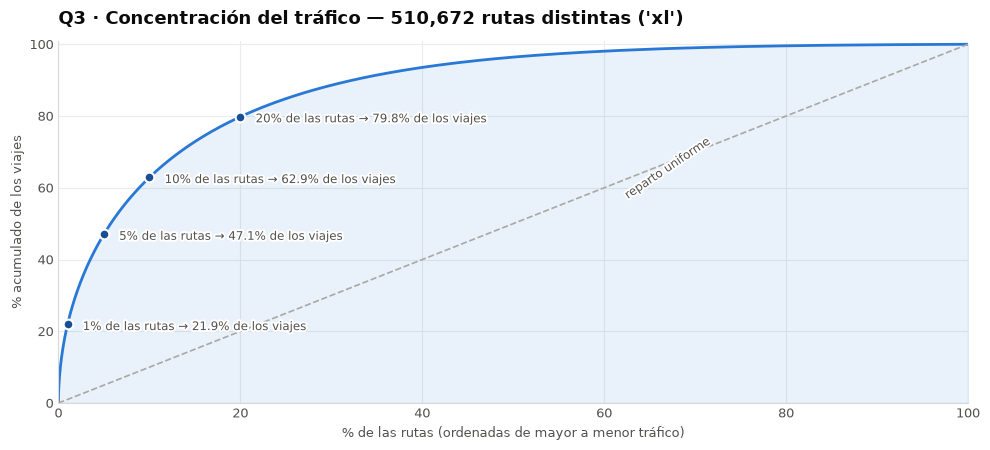

Rutas distintas                      : 510,672
Pares posibles (estaciones²)         : 643,204  -> se usa el 79.4% de la matriz origen-destino
El  1% de las rutas concentra       :  21.9% de los viajes
El  5% de las rutas concentra       :  47.1% de los viajes
El 10% de las rutas concentra       :  62.9% de los viajes
El 20% de las rutas concentra       :  79.8% de los viajes
Rutas con un solo viaje              : 52,815 (10.3% de las rutas)
Viajes circulares (origen = destino) : 1,653,739 (4.3% del total, en 806 estaciones)


In [36]:
# Curva de concentración (Pareto). Una sola serie -> sin leyenda; el título la nombra.
n_rutas   = len(q3)
eje_rutas = np.arange(1, n_rutas + 1) / n_rutas * 100
acum      = q3["pct_acum"].to_numpy()

fig, ax = plt.subplots(figsize=(10, 4.6))
ax.plot(eje_rutas, acum, linewidth=2, color="#2a78d6")
ax.fill_between(eje_rutas, acum, color="#2a78d6", alpha=0.10)
ax.plot([0, 100], [0, 100], linewidth=1.2, linestyle="--", color="#a9a8a4")
ax.text(62, 57, "reparto uniforme", rotation=34, fontsize=8.5, color=TINTA2,
        path_effects=HALO)

hitos = {}
for corte in (1, 5, 10, 20):
    idx = max(int(n_rutas * corte / 100) - 1, 0)
    hitos[corte] = acum[idx]
    ax.plot([corte], [acum[idx]], "o", color="#184f95", markersize=7,
            markeredgecolor="white", markeredgewidth=1.5)
    # offset fijo y pequeño: cada etiqueta queda pegada a SU punto, sin apilarse
    ax.annotate(f"{corte}% de las rutas → {acum[idx]:.1f}% de los viajes",
                xy=(corte, acum[idx]), xytext=(11, -4), textcoords="offset points",
                fontsize=8.5, color=TINTA2, path_effects=HALO)

ax.set_xlabel("% de las rutas (ordenadas de mayor a menor tráfico)", color=TINTA2, fontsize=9)
ax.set_ylabel("% acumulado de los viajes", color=TINTA2, fontsize=9)
ax.set_xlim(0, 100); ax.set_ylim(0, 101)
ax.set_title(f"Q3 · Concentración del tráfico — {n_rutas:,} rutas distintas ('{V_RESP}')",
             color=TINTA, fontsize=13, fontweight="bold", loc="left", pad=12)
estilo_ejes(ax)
fig.tight_layout()
fig.savefig(DIR_SALIDA / f"q3_pareto_{V_RESP}.png", dpi=160, facecolor="white")
plt.show()

circ     = q3["start_station_id"] == q3["end_station_id"]
v_circ   = int(q3.loc[circ, "viajes"].sum())
v_total  = int(q3["viajes"].sum())
una_vez  = int((q3["viajes"] == 1).sum())
posibles = len(estaciones) ** 2

print(f"Rutas distintas                      : {n_rutas:,}")
print(f"Pares posibles (estaciones²)         : {posibles:,}  "
      f"-> se usa el {100*n_rutas/posibles:.1f}% de la matriz origen-destino")
for c, v in hitos.items():
    print(f"El {c:2d}% de las rutas concentra       : {v:5.1f}% de los viajes")
print(f"Rutas con un solo viaje              : {una_vez:,} "
      f"({100*una_vez/n_rutas:.1f}% de las rutas)")
print(f"Viajes circulares (origen = destino) : {v_circ:,} "
      f"({100*v_circ/v_total:.1f}% del total, en {int(circ.sum()):,} estaciones)")

---
## 8. Exportar resultados

In [37]:
guardar_registro()

q1.to_csv(DIR_SALIDA / f"q1_demanda_{V_RESP}.csv", index=False, encoding="utf-8")
q2_nom.to_csv(DIR_SALIDA / f"q2_desequilibrio_{V_RESP}.csv", index=False, encoding="utf-8")
q3.head(1000).to_csv(DIR_SALIDA / f"q3_rutas_top1000_{V_RESP}.csv",
                     index=False, encoding="utf-8")
tabla_versiones.to_csv(DIR_SALIDA / "versiones_dataset.csv", encoding="utf-8")

bench_final = pd.read_csv(ruta_benchmarks())
print(f"{len(bench_final)} mediciones acumuladas en {ruta_benchmarks().name}")
print()
print("SEGUNDOS TOTALES POR ETAPA Y HERRAMIENTA")
print(bench_final.pivot_table(index="version", columns=["etapa", "herramienta"],
                              values="seg_total", aggfunc="sum").round(1).to_string())
print()
print("Archivos en salida/:")
for p in sorted(DIR_SALIDA.iterdir()):
    print(f"   {p.name:52s} {p.stat().st_size/1024:9,.1f} KB")

19 mediciones acumuladas en benchmarks_jesus-macbook.csv

SEGUNDOS TOTALES POR ETAPA Y HERRAMIENTA
etapa         base                etl optimizado                      
herramienta duckdb pandas sqlite  etl duckdb-opt pandas-opt sqlite-opt
version                                                               
xl            27.3  195.4  472.6  6.3        2.7        3.4      291.5

Archivos en salida/:
   benchmarks_jesus-macbook.csv                               1.8 KB
   fase2_carga_vs_query_jesus-macbook.png                    50.0 KB
   fase2_escalado_jesus-macbook.png                          75.1 KB
   fase3_impacto_jesus-macbook.png                           42.0 KB
   ficha_tecnica_jesus-macbook.json                           0.4 KB
   q1_demanda_xl.csv                                          1.9 KB
   q1_heatmap_xl.png                                         67.1 KB
   q1_perfil_horario_xl.png                                  93.8 KB
   q2_desequilibrio_xl.csv                 

In [38]:
# Limpieza: cerrar lo que quede abierto y liberar el disco de trabajo.
# Poner BORRAR_ARTEFACTOS=True si hace falta recuperar espacio; si se dejan,
# una nueva corrida los reutiliza y se salta el ETL.
BORRAR_ARTEFACTOS = False

gc.collect()
if BORRAR_ARTEFACTOS:
    for p in DIR_TRABAJO.glob("*"):
        try:
            p.unlink()
            print(f"   borrado {p.name}")
        except OSError as e:
            print(f"   no se pudo borrar {p.name}: {e}")
else:
    _tot = sum(p.stat().st_size for p in DIR_TRABAJO.glob("*")) / 1024**3
    print(f"Artefactos conservados en {DIR_TRABAJO} ({_tot:,.2f} GB). "
          f"Se reutilizan en la próxima corrida.")

Artefactos conservados en /var/folders/8x/_m9bxv6d3ng8kgfxgzq1bdwr0000gn/T/proyecto_bigdata (0.93 GB). Se reutilizan en la próxima corrida.
